# Pipeline ML — Calidad del Agua Río Cauca
**Maestría en Ciencia de Datos | Pontificia Universidad Javeriana Cali | 2025–2026**

Objetivos: Predicción de **DBO** (Demanda Bioquímica de Oxígeno) y **pH**  
Pipeline: EDA → Imputación KNN → Correlaciones → VIF → RFE → 6 modelos × 4 escenarios → Grid Search + Optuna → SHAP + Permutation Importance

---
## SECCIÓN 1 — LIBRERÍAS

In [3]:
%pip install optuna -q
%pip install xgboost -q
%pip install pandas -q
%pip install scikit-learn -q
%pip install shap -q
%pip install statsmodels -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print('Kernel Python:', sys.executable)
!{sys.executable} -m pip install -U pip -q
!{sys.executable} -m pip install -U xgboost -q
!{sys.executable} -m pip show xgboost

Kernel Python: /usr/bin/python3
Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /home/dackarl/.local/lib/python3.10/site-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: 


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, HTML, Text, VBox, HBox, Layout
from IPython.display import display
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    cross_val_score, KFold, RepeatedKFold,
    learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna
import os, json, joblib, sys, platform, time, warnings
from datetime import datetime
from math import sqrt
import shap
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
artefactos = {}

print('Librerías cargadas correctamente')
print(f'XGBoost: {xgb.__version__} | Optuna: {optuna.__version__}')

Librerías cargadas correctamente
XGBoost: 3.2.0 | Optuna: 4.4.0


---
## SECCIÓN 2 — CARGA DE DATOS Y DICCIONARIO

In [6]:
import importlib, diccionario
importlib.reload(diccionario)
print('¿Está diccionario_variables?:', hasattr(diccionario, 'diccionario_variables'))
print(f'Total variables en diccionario: {len(diccionario.diccionario_variables)}')

¿Está diccionario_variables?: True
Total variables en diccionario: 53


In [7]:
df = pd.read_csv('Calidad_del_agua_del_Rio_Cauca.csv', sep=';')
print(f'Shape original: {df.shape}')
df.head()

Shape original: (2254, 56)


,FECHA DE MUESTREO,ESTACIONES,pH,TEMPERATURA (°C),COLOR (UPC),TURBIEDAD (UNT),SOLIDOS TOTALES (mg SST/l),SOLIDOS SUSPENDIDOS TOTALES (mg SS/l),SOLIDOS DISUELTOS (mg SD/l),DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l),...,CROMO TOTAL (mg Cr/l),CROMO DISUELTO (mg Cr/l),NIQUEL TOTAL (mg Ni/l),NIQUEL DISUELTO (mg Ni/l),PLOMO TOTAL (mg Pb/l),PLOMO DISUELTO (mg Pb/l),MERCURIO (µg Hg/l),COLIFORMES TOTALES (NMP/100 ml),COLIFORMES FECALES (NMP/100 ml),CAUDAL (m3/s)
0,12/19/1998 12:00:00 AM,YOTOCO,7.1,4.1,NaN,4.1,NaN,110,NaN,4.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12/19/1998 12:00:00 AM,MEDIACANOA,7,2,NaN,2,NaN,130,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12/19/1998 12:00:00 AM,PASO DE LA TORRE,7,22.9,NaN,3.4,NaN,153.3,NaN,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5/09/1990 0:00,ANTES SUAREZ,6.6,NaN,NaN,NaN,157.0,29.3,127.7,0.5,...,NaN,NaN,0,NaN,NaN,NaN,NaN,2.4*10E4,23,NaN
4,1/10/1990 0:00,ANTES RIO OVEJAS,6.7,NaN,NaN,NaN,143.0,65,78,2.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.4*10E4,24*10E4,NaN


In [8]:
df_sin_columnas = df.drop(columns=['FECHA DE MUESTREO', 'ESTACIONES'])
print(f'Shape sin fecha/estación: {df_sin_columnas.shape}')
df_sin_columnas.head()

Shape sin fecha/estación: (2254, 54)


,pH,TEMPERATURA (°C),COLOR (UPC),TURBIEDAD (UNT),SOLIDOS TOTALES (mg SST/l),SOLIDOS SUSPENDIDOS TOTALES (mg SS/l),SOLIDOS DISUELTOS (mg SD/l),DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l),DEMANDA QUIMICA DE OXIGENO (mg O2/l),OXIGENO DISUELTO (mg O2/l),...,CROMO TOTAL (mg Cr/l),CROMO DISUELTO (mg Cr/l),NIQUEL TOTAL (mg Ni/l),NIQUEL DISUELTO (mg Ni/l),PLOMO TOTAL (mg Pb/l),PLOMO DISUELTO (mg Pb/l),MERCURIO (µg Hg/l),COLIFORMES TOTALES (NMP/100 ml),COLIFORMES FECALES (NMP/100 ml),CAUDAL (m3/s)
0,7.1,4.1,NaN,4.1,NaN,110,NaN,4.2,NaN,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,2,NaN,2,NaN,130,NaN,3,NaN,1.81,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7,22.9,NaN,3.4,NaN,153.3,NaN,5,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.6,NaN,NaN,NaN,157.0,29.3,127.7,0.5,5.2,5.6,...,NaN,NaN,0,NaN,NaN,NaN,NaN,2.4*10E4,23,NaN
4,6.7,NaN,NaN,NaN,143.0,65,78,2.1,24,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.4*10E4,24*10E4,NaN


In [9]:
# Widget interactivo visor del diccionario
dic = diccionario.diccionario_variables
opciones = ['-- Seleccionar variable --'] + list(dic.keys())

dropdown = Dropdown(
    options=opciones,
    description='Variable:',
    layout=Layout(width='60%')
)
output_html = HTML(value='<i>Selecciona una variable del menú.</i>')

def on_change(change):
    sel = change['new']
    if sel == '-- Seleccionar variable --':
        output_html.value = '<i>Selecciona una variable del menú.</i>'
        return
    info = dic.get(sel, {})
    filas = ''.join(
        f'<tr><td style="font-weight:bold;padding:4px 12px">{k}</td><td style="padding:4px">{v}</td></tr>'
        for k, v in info.items()
    )
    output_html.value = f'<table style="border-collapse:collapse">{filas}</table>'

dropdown.observe(on_change, names='value')
display(VBox([dropdown, output_html]))

---
## SECCIÓN 3 — EDA (ANÁLISIS EXPLORATORIO DE DATOS)

In [10]:
df_eda = df_sin_columnas.copy()
for columna in df_eda.columns:
    df_eda[columna] = pd.to_numeric(
        df_eda[columna].astype(str).str.replace(',', '.'),
        errors='coerce'
    )
df_eda.dropna(axis='columns', how='all', inplace=True)
print(f'Shape tras limpieza numérica: {df_eda.shape}')
df_eda.info()

Shape tras limpieza numérica: (2254, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2254 entries, 0 to 2253
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   pH                                       2208 non-null   float64
 1   TEMPERATURA (°C)                         1956 non-null   float64
 2   COLOR (UPC)                              1882 non-null   float64
 3   TURBIEDAD (UNT)                          2090 non-null   float64
 4   SOLIDOS TOTALES (mg SST/l)               2194 non-null   float64
 5   SOLIDOS SUSPENDIDOS TOTALES (mg SS/l)    2188 non-null   float64
 6   SOLIDOS DISUELTOS (mg SD/l)              2190 non-null   float64
 7   DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l)  2092 non-null   float64
 8   DEMANDA QUIMICA DE OXIGENO (mg O2/l)     2066 non-null   float64
 9   OXIGENO DISUELTO (mg O2/l)               2179 non-null   float64
 10  DUREZA 

In [11]:
# Estadísticas descriptivas completas
from scipy.stats import skew, kurtosis, sem

stats_rows = []
for col in df_eda.columns:
    s = df_eda[col].dropna()
    n_valid = len(s)
    n_total = len(df_eda)
    pct_valid = round(n_valid / n_total * 100, 2)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    mad = (s - s.median()).abs().median()
    cv = (s.std() / s.mean() * 100) if s.mean() != 0 else np.nan
    sk = skew(s)
    se_sk = np.sqrt(6 * n_valid * (n_valid - 1) / ((n_valid - 2) * (n_valid + 1) * (n_valid + 3))) if n_valid > 3 else np.nan
    kurt = kurtosis(s)
    stats_rows.append({
        'Variable': col,
        'N.Valid': int(n_valid),
        'Pct.Valid': pct_valid,
        'Mean': round(s.mean(), 2),
        'Std.Dev': round(s.std(), 2),
        'Min': round(s.min(), 2),
        'Q1': round(q1, 2),
        'Median': round(s.median(), 2),
        'Q3': round(q3, 2),
        'Max': round(s.max(), 2),
        'IQR': round(iqr, 2),
        'MAD': round(mad, 2),
        'CV': round(cv, 2),
        'Skewness': round(sk, 2),
        'SE.Skewness': round(se_sk, 4) if not np.isnan(se_sk) else np.nan,
        'Kurtosis': round(kurt, 2)
    })

estadisticas_completas = pd.DataFrame(stats_rows).set_index('Variable')
print(f'Variables analizadas: {len(estadisticas_completas)}')
estadisticas_completas

Variables analizadas: 39


,N.Valid,Pct.Valid,Mean,Std.Dev,Min,Q1,Median,Q3,Max,IQR,MAD,CV,Skewness,SE.Skewness,Kurtosis
Variable,,,,,,,,,,,,,,,
pH,2208,97.96,7.040000e+00,4.100000e-01,4.10,6.80,7.07,7.28,9.700000e+00,0.48,0.23,5.77,-0.10,0.0521,5.21
TEMPERATURA (°C),1956,86.78,2.202000e+01,3.600000e+00,0.00,21.00,22.40,24.10,3.270000e+01,3.10,1.60,16.36,-2.34,0.0553,8.90
COLOR (UPC),1882,83.50,1.354500e+02,2.445800e+02,0.00,38.50,70.00,134.75,2.956000e+03,96.25,37.50,180.57,6.15,0.0564,49.40
TURBIEDAD (UNT),2090,92.72,1.307300e+02,1.710300e+02,1.00,30.00,65.00,156.15,1.900000e+03,126.15,45.00,130.83,2.86,0.0535,12.09
SOLIDOS TOTALES (mg SST/l),2194,97.34,2.751900e+02,2.276200e+02,0.00,142.00,206.00,324.00,2.361000e+03,182.00,80.50,82.72,3.14,0.0523,15.65
SOLIDOS SUSPENDIDOS TOTALES (mg SS/l),2188,97.07,1.652000e+02,2.029100e+02,1.20,41.00,92.65,216.25,2.112000e+03,175.25,65.65,122.83,3.06,0.0523,14.31
SOLIDOS DISUELTOS (mg SD/l),2190,97.16,1.175100e+02,6.364000e+01,0.00,83.00,108.00,136.00,8.644000e+02,53.00,26.40,54.16,3.88,0.0523,28.67
DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l),2092,92.81,5.220000e+00,1.625000e+01,0.10,2.08,3.10,4.80,4.270000e+02,2.72,1.28,311.02,16.24,0.0535,332.66
DEMANDA QUIMICA DE OXIGENO (mg O2/l),2066,91.66,2.989000e+01,3.729000e+01,1.46,14.10,20.72,31.98,7.060000e+02,17.88,8.07,124.76,7.23,0.0539,87.73


In [12]:
# Filtro de completitud ≥ 80%
umbral = 80
vars_baja_completitud = estadisticas_completas[estadisticas_completas['Pct.Valid'] < umbral]
print(f'Variables con menos del {umbral}% de datos válidos: {len(vars_baja_completitud)}')
display(vars_baja_completitud[['Pct.Valid', 'N.Valid']])

Variables con menos del 80% de datos válidos: 12


,Pct.Valid,N.Valid
Variable,,
MANGANESO TOTAL (mg Mn/l),70.72,1594
COBRE TOTAL (mg Cu/l),23.82,537
ZINC TOTAL (mg Zn/l),46.10,1039
NITROGENO TOTAL (mg N/l),58.65,1322
NITROGENO AMONIACAL (mg N-NH3/l),57.14,1288
FOSFORO TOTAL (mg P/l),79.72,1797
FOSFATOS (mg PO4/l),49.38,1113
CADMIO TOTAL (mg Cd/l),4.44,100
CROMO TOTAL (mg Cr/l),8.65,195


In [13]:
# Crear df_filtrado con variables ≥ 80% completitud
columnas_mantener = estadisticas_completas[estadisticas_completas['Pct.Valid'] >= umbral].index.tolist()
df_filtrado = df_eda[columnas_mantener].copy()
print(f'Variables conservadas: {len(columnas_mantener)}')
print(columnas_mantener)

Variables conservadas: 27
['pH', 'TEMPERATURA (°C)', 'COLOR (UPC)', 'TURBIEDAD (UNT)', 'SOLIDOS TOTALES (mg SST/l)', 'SOLIDOS SUSPENDIDOS TOTALES (mg SS/l)', 'SOLIDOS DISUELTOS (mg SD/l)', 'DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l)', 'DEMANDA QUIMICA DE OXIGENO (mg O2/l)', 'OXIGENO DISUELTO (mg O2/l)', 'DUREZA TOTAL (mg CaCO3/l)', 'DUREZA CALCICA (mg CaCO3/l)', 'DUREZA MAGNESICA (mg CaCO3/l)', 'CALCIO (mg Ca/l)', 'MAGNESIO (mg Mg/l)', 'ALCALINIDAD TOTAL (mg CaCO3/l)', 'BICARBONATOS (mg CaCO3/l)', 'CONDUCTIVIDAD ELÉCTRICA (µS/cm)', 'HIERRO TOTAL (mg Fe/l)', 'SODIO TOTAL (mg Na/l)', 'POTASIO TOTAL (mg K/l)', 'NITRITOS (mg N-NO2/l)', 'NITRATOS (mg N-NO3/l)', 'CLORUROS (mg Cl/l)', 'SULFATOS (mg SO4/l)', 'COLIFORMES TOTALES (NMP/100 ml)', 'COLIFORMES FECALES (NMP/100 ml)']


In [14]:
# Definición de variables objetivo
OBJ_DBO = 'DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l)'
OBJ_PH  = 'pH'
objetivos = [OBJ_DBO, OBJ_PH]
print('Objetivos:', objetivos)
assert OBJ_DBO in df_filtrado.columns, f'ERROR: {OBJ_DBO} no encontrado'
assert OBJ_PH  in df_filtrado.columns, f'ERROR: {OBJ_PH} no encontrado'

Objetivos: ['DEMANDA BIOQUIMICA DE OXIGENO (mg O2/l)', 'pH']


In [15]:
def get_X_y_para(objetivo):
    """Retorna X (predictores) e y (objetivo), alineados, sin NaN en ninguno."""
    otros_objetivos = [o for o in objetivos if o != objetivo]
    cols_pred = [
        c for c in df_filtrado.columns
        if c != objetivo
        and c not in otros_objetivos
        and df_filtrado[c].nunique() > 1
        and pd.api.types.is_numeric_dtype(df_filtrado[c])
    ]
    tmp = df_filtrado[cols_pred + [objetivo]].dropna()
    X = tmp[cols_pred]
    y = tmp[objetivo]
    print(f'[{objetivo[:30]}] X: {X.shape} | y: {y.shape}')
    return X, y

X_dbo, y_dbo = get_X_y_para(OBJ_DBO)
X_ph,  y_ph  = get_X_y_para(OBJ_PH)

[DEMANDA BIOQUIMICA DE OXIGENO ] X: (837, 25) | y: (837,)
[pH] X: (874, 25) | y: (874,)


---
## SECCIÓN 4 — IMPUTACIÓN KNN

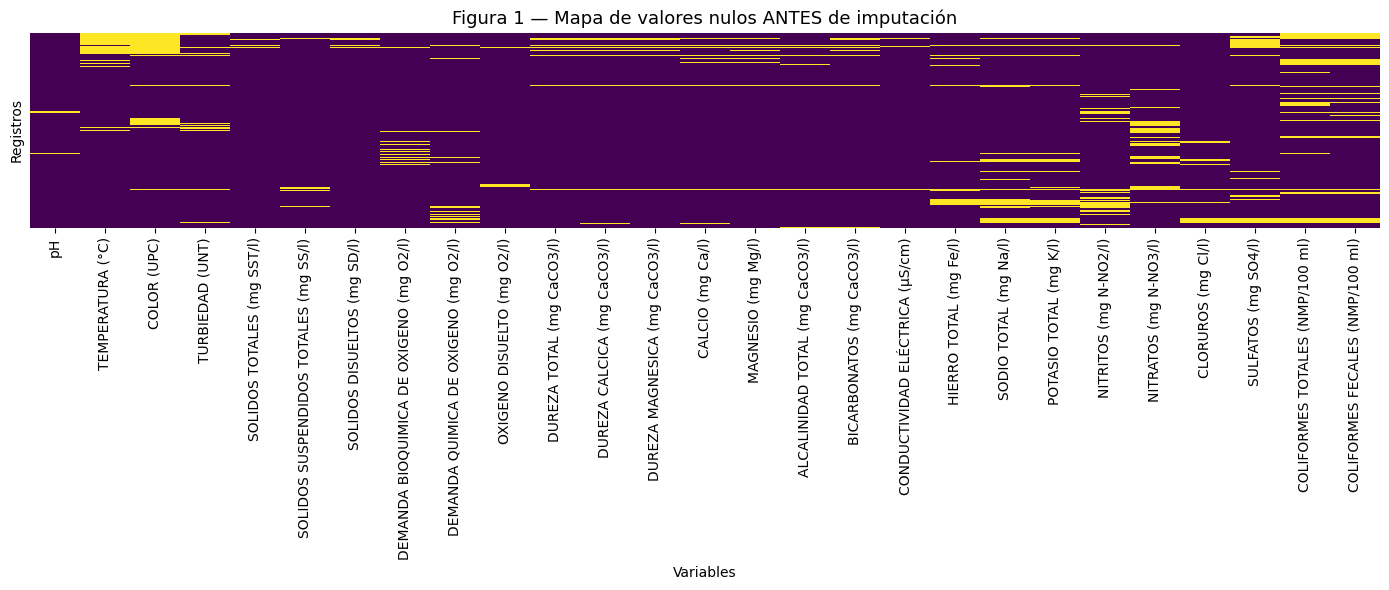

In [16]:
# Figura 1 — Mapa de nulos ANTES de imputación
plt.figure(figsize=(14, 6))
sns.heatmap(df_filtrado.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Figura 1 — Mapa de valores nulos ANTES de imputación', fontsize=13)
plt.xlabel('Variables')
plt.ylabel('Registros')
plt.tight_layout()
plt.show()

In [17]:
# Imputación KNN: Escalar → Imputar → Desescalar
scaler_imp = StandardScaler()
df_scaled = pd.DataFrame(
    scaler_imp.fit_transform(df_filtrado),
    columns=df_filtrado.columns
)

imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed_scaled = pd.DataFrame(
    imputer.fit_transform(df_scaled),
    columns=df_scaled.columns
)

df_imputed = pd.DataFrame(
    scaler_imp.inverse_transform(df_imputed_scaled),
    columns=df_filtrado.columns
)

print(f'Nulos restantes: {df_imputed.isnull().sum().sum()}')  # debe ser 0
print(f'Shape df_imputed: {df_imputed.shape}')

Nulos restantes: 0
Shape df_imputed: (2254, 27)


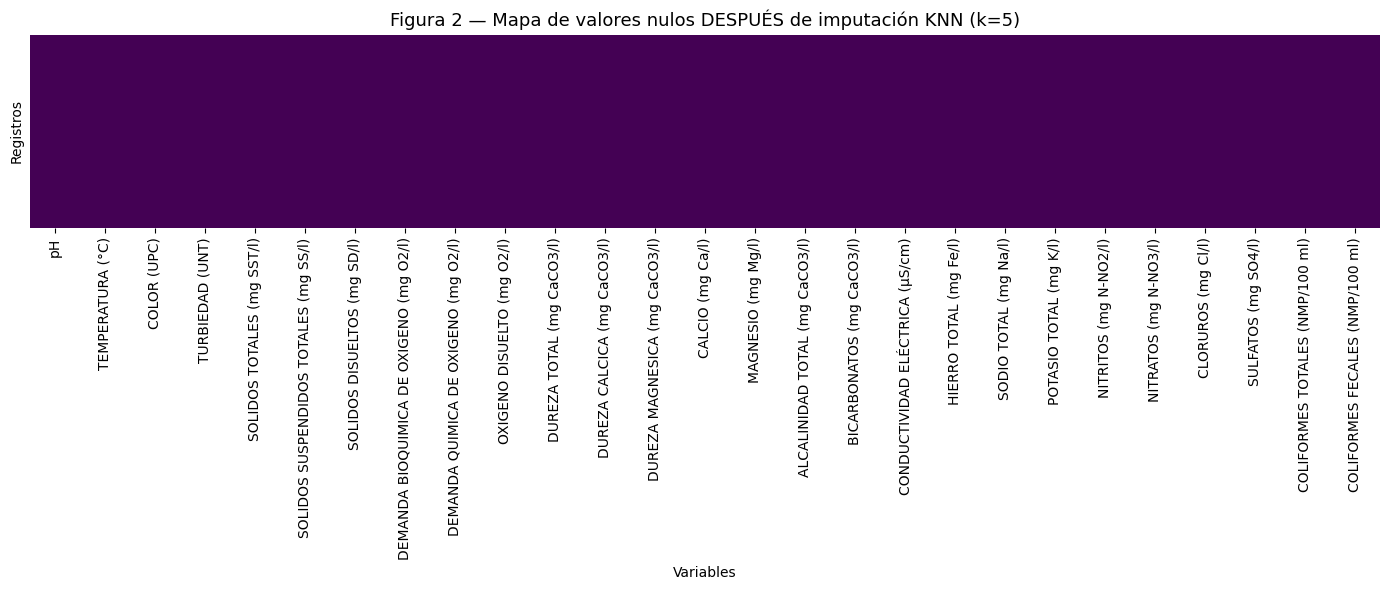

In [18]:
# Figura 2 — Mapa de nulos DESPUÉS de imputación
plt.figure(figsize=(14, 6))
sns.heatmap(df_imputed.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Figura 2 — Mapa de valores nulos DESPUÉS de imputación KNN (k=5)', fontsize=13)
plt.xlabel('Variables')
plt.ylabel('Registros')
plt.tight_layout()
plt.show()

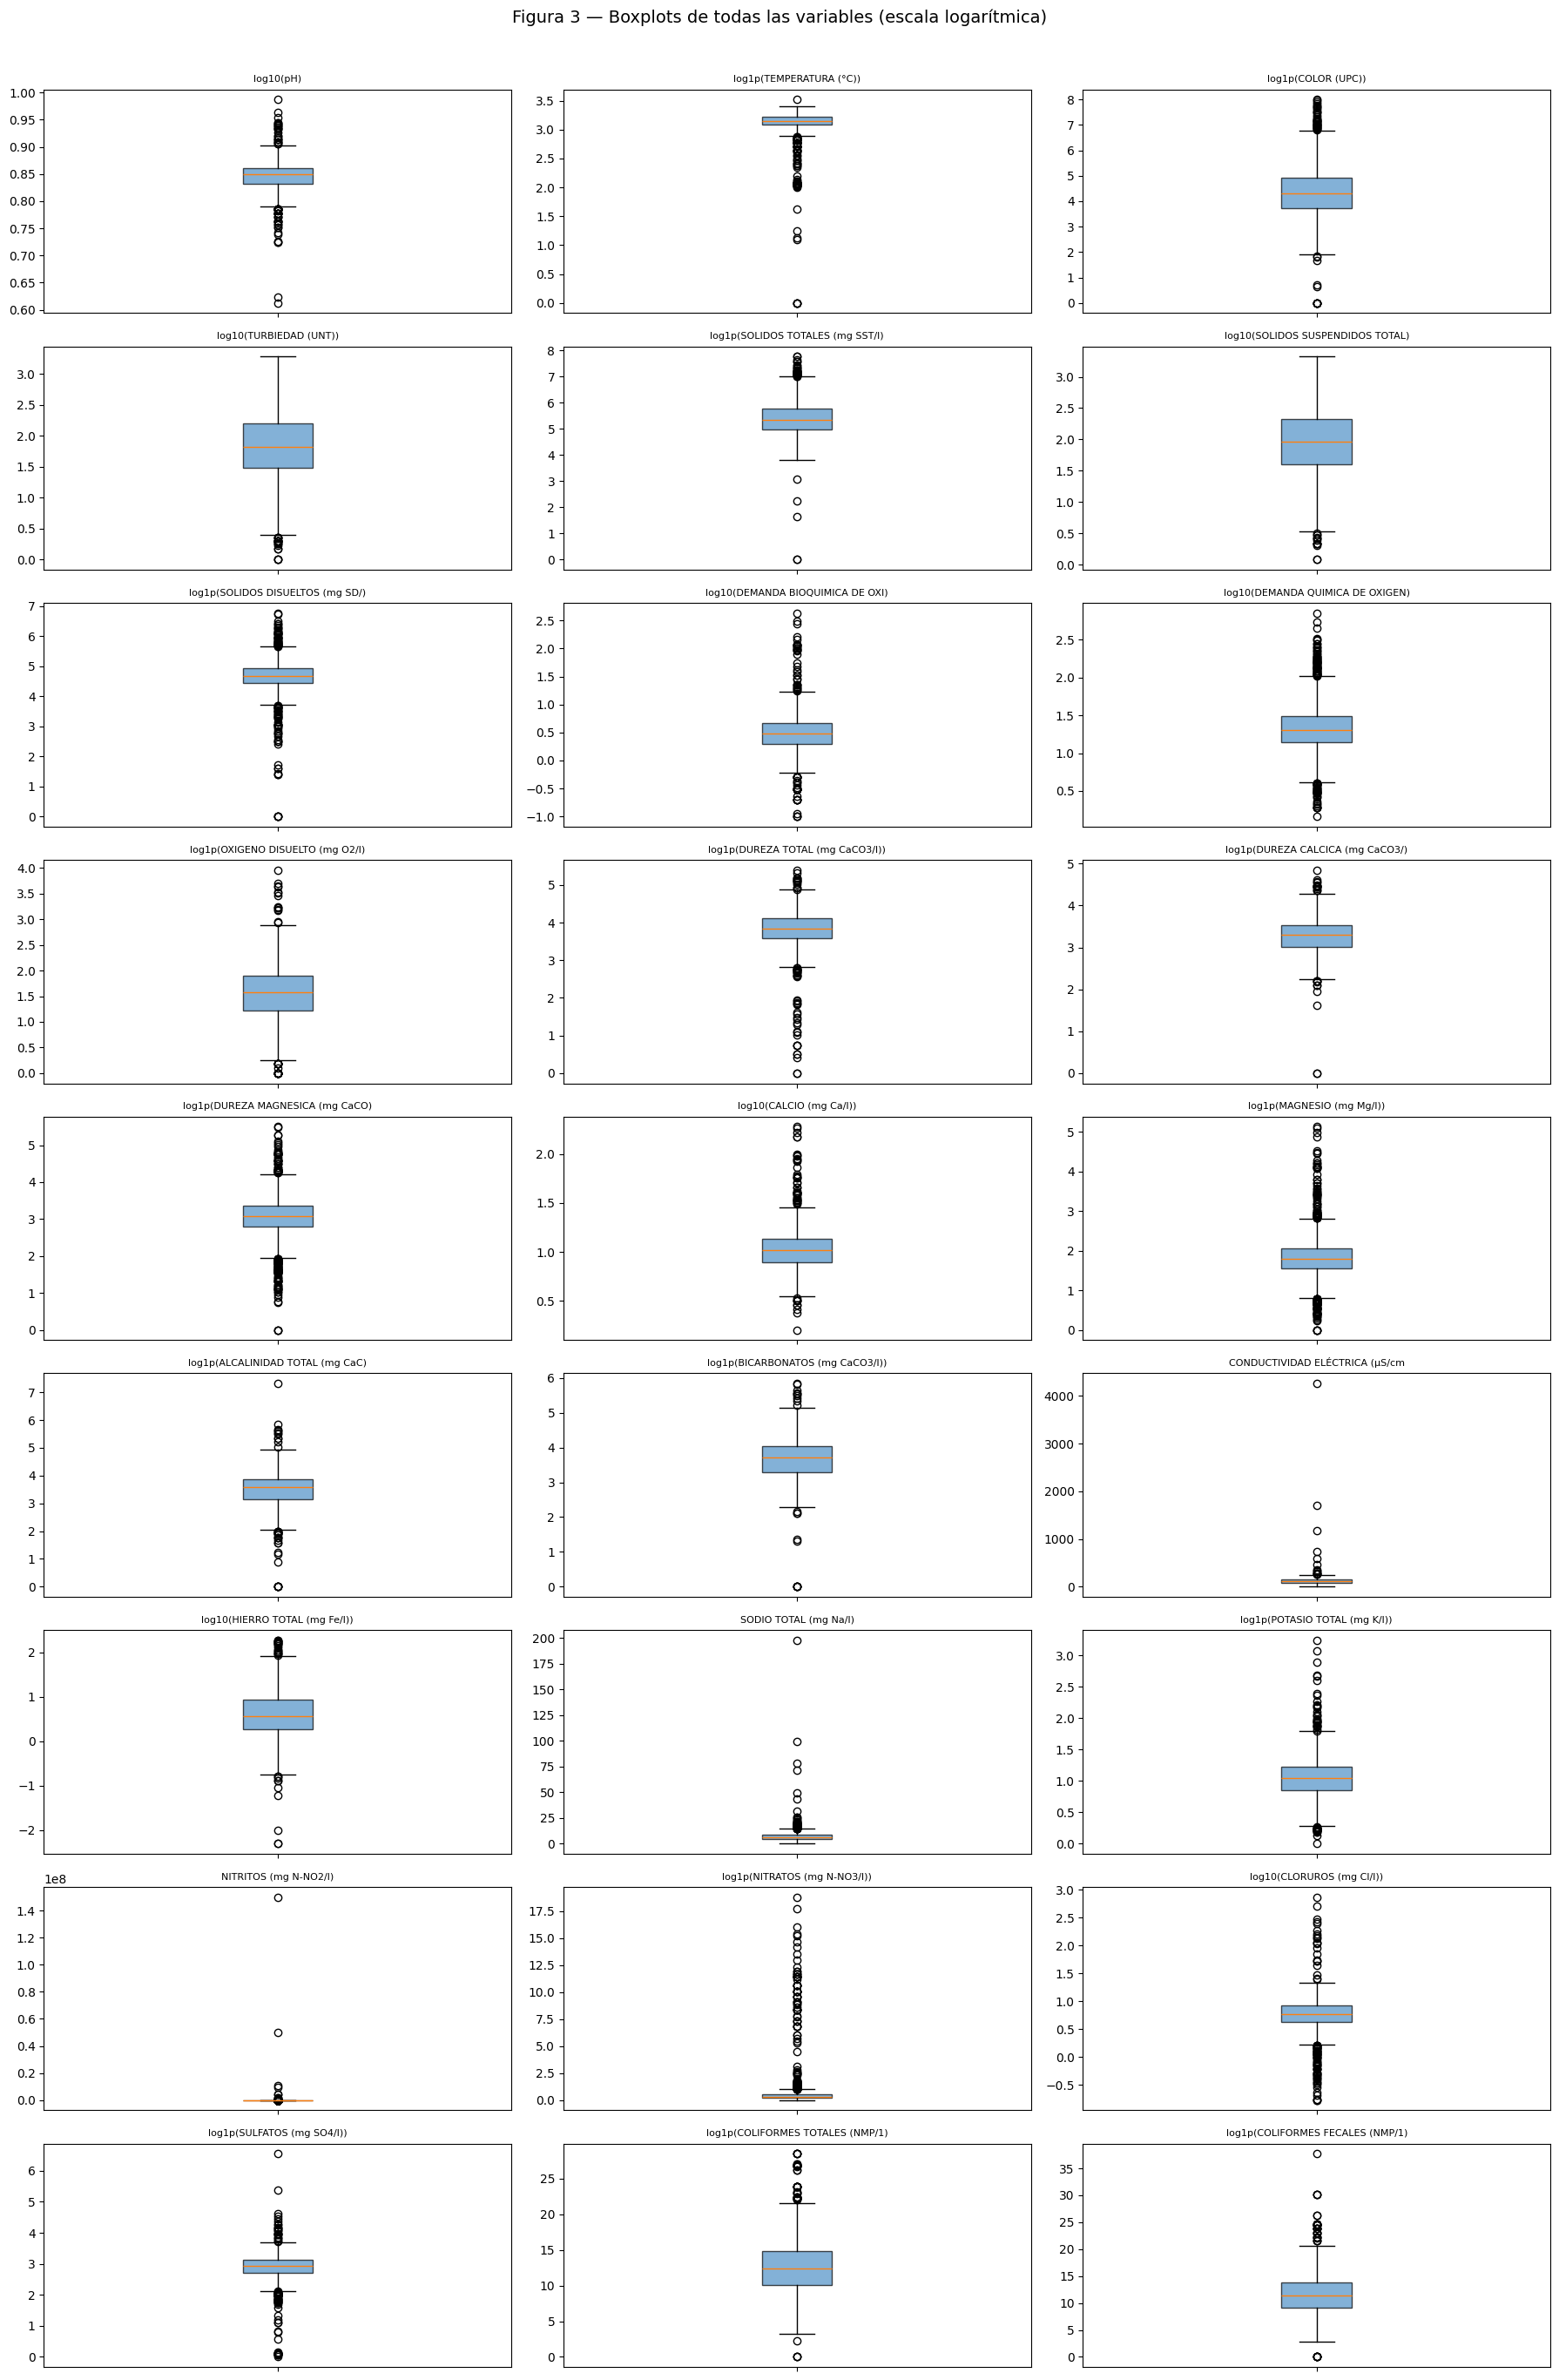

In [19]:
# Figura 3 — Boxplots de todas las variables (transformación log segura)
cols_plot = df_imputed.columns.tolist()
n_cols = 3
n_rows = int(np.ceil(len(cols_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    s = df_imputed[col]
    if (s > 0).all():
        datos = np.log10(s)
        etiqueta = f'log10({col[:25]})'
    elif (s >= 0).all():
        datos = np.log1p(s)
        etiqueta = f'log1p({col[:25]})'
    else:
        datos = s
        etiqueta = col[:30]
    axes[i].boxplot(datos.dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4E91C7', alpha=0.7))
    axes[i].set_title(etiqueta, fontsize=8)
    axes[i].tick_params(axis='x', labelbottom=False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Figura 3 — Boxplots de todas las variables (escala logarítmica)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# Análisis especial: Nitritos y Conductividad Eléctrica
vars_especiales = [
    c for c in df_imputed.columns
    if 'NITRITO' in c.upper() or 'CONDUCTIVIDAD' in c.upper()
]

for col in vars_especiales:
    s = df_imputed[col]
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    from scipy.stats import skew as _skew, kurtosis as _kurt
    print(f'\n--- {col} ---')
    print(f'  Mediana: {s.median():.4f} | Máx: {s.max():.2f}')
    print(f'  Skewness: {_skew(s):.2f} | Kurtosis: {_kurt(s):.2f}')
    print(f'  Outliers IQR: {outliers} ({outliers/len(s)*100:.2f}%)')


--- CONDUCTIVIDAD ELÉCTRICA (µS/cm) ---
  Mediana: 117.0000 | Máx: 4259.00
  Skewness: 28.36 | Kurtosis: 1049.88
  Outliers IQR: 14 (0.62%)

--- NITRITOS (mg N-NO2/l) ---
  Mediana: 0.0251 | Máx: 150000000.00
  Skewness: 41.40 | Kurtosis: 1806.82
  Outliers IQR: 446 (19.79%)


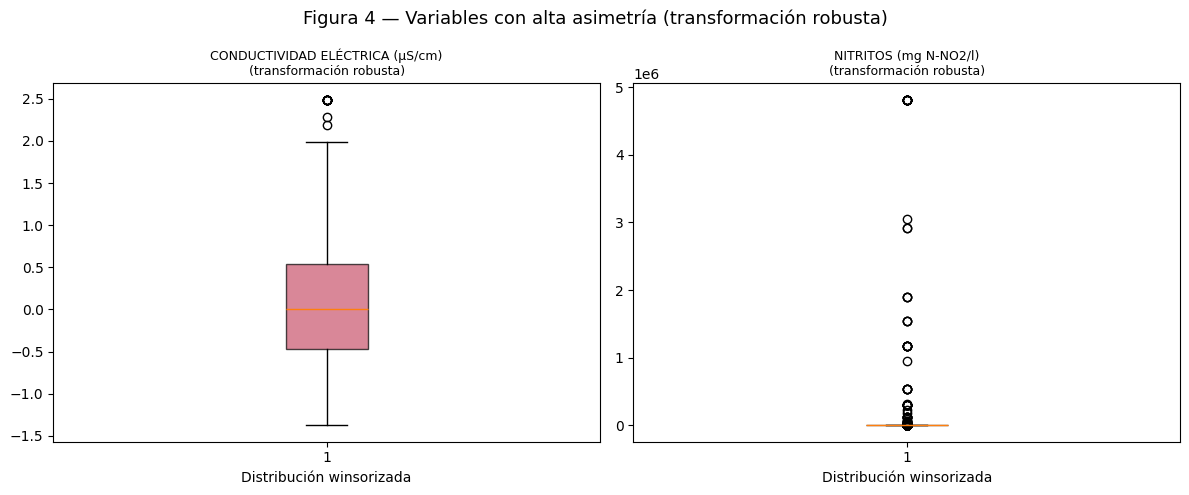

In [21]:
# Función transformación robusta para visualización
def transform_robusta_para_plot(s, p_low=0.005, p_high=0.995):
    eps = 1e-9
    if (s >= 0).all():
        s_t = np.log10(s + eps)
    else:
        med = s.median()
        iqr = s.quantile(0.75) - s.quantile(0.25)
        s_t = (s - med) / (iqr + eps)
    lo, hi = s_t.quantile(p_low), s_t.quantile(p_high)
    return s_t.clip(lo, hi)

# Figura 4 — Boxplots Nitritos y Conductividad (transformación robusta)
fig, axes = plt.subplots(1, len(vars_especiales), figsize=(6 * len(vars_especiales), 5))
if len(vars_especiales) == 1:
    axes = [axes]

for ax, col in zip(axes, vars_especiales):
    datos = transform_robusta_para_plot(df_imputed[col])
    ax.boxplot(datos, patch_artist=True,
               boxprops=dict(facecolor='#C9546C', alpha=0.7))
    ax.set_title(f'{col[:40]}\n(transformación robusta)', fontsize=9)
    ax.set_xlabel('Distribución winsorizada')

fig.suptitle('Figura 4 — Variables con alta asimetría (transformación robusta)', fontsize=13)
plt.tight_layout()
plt.show()

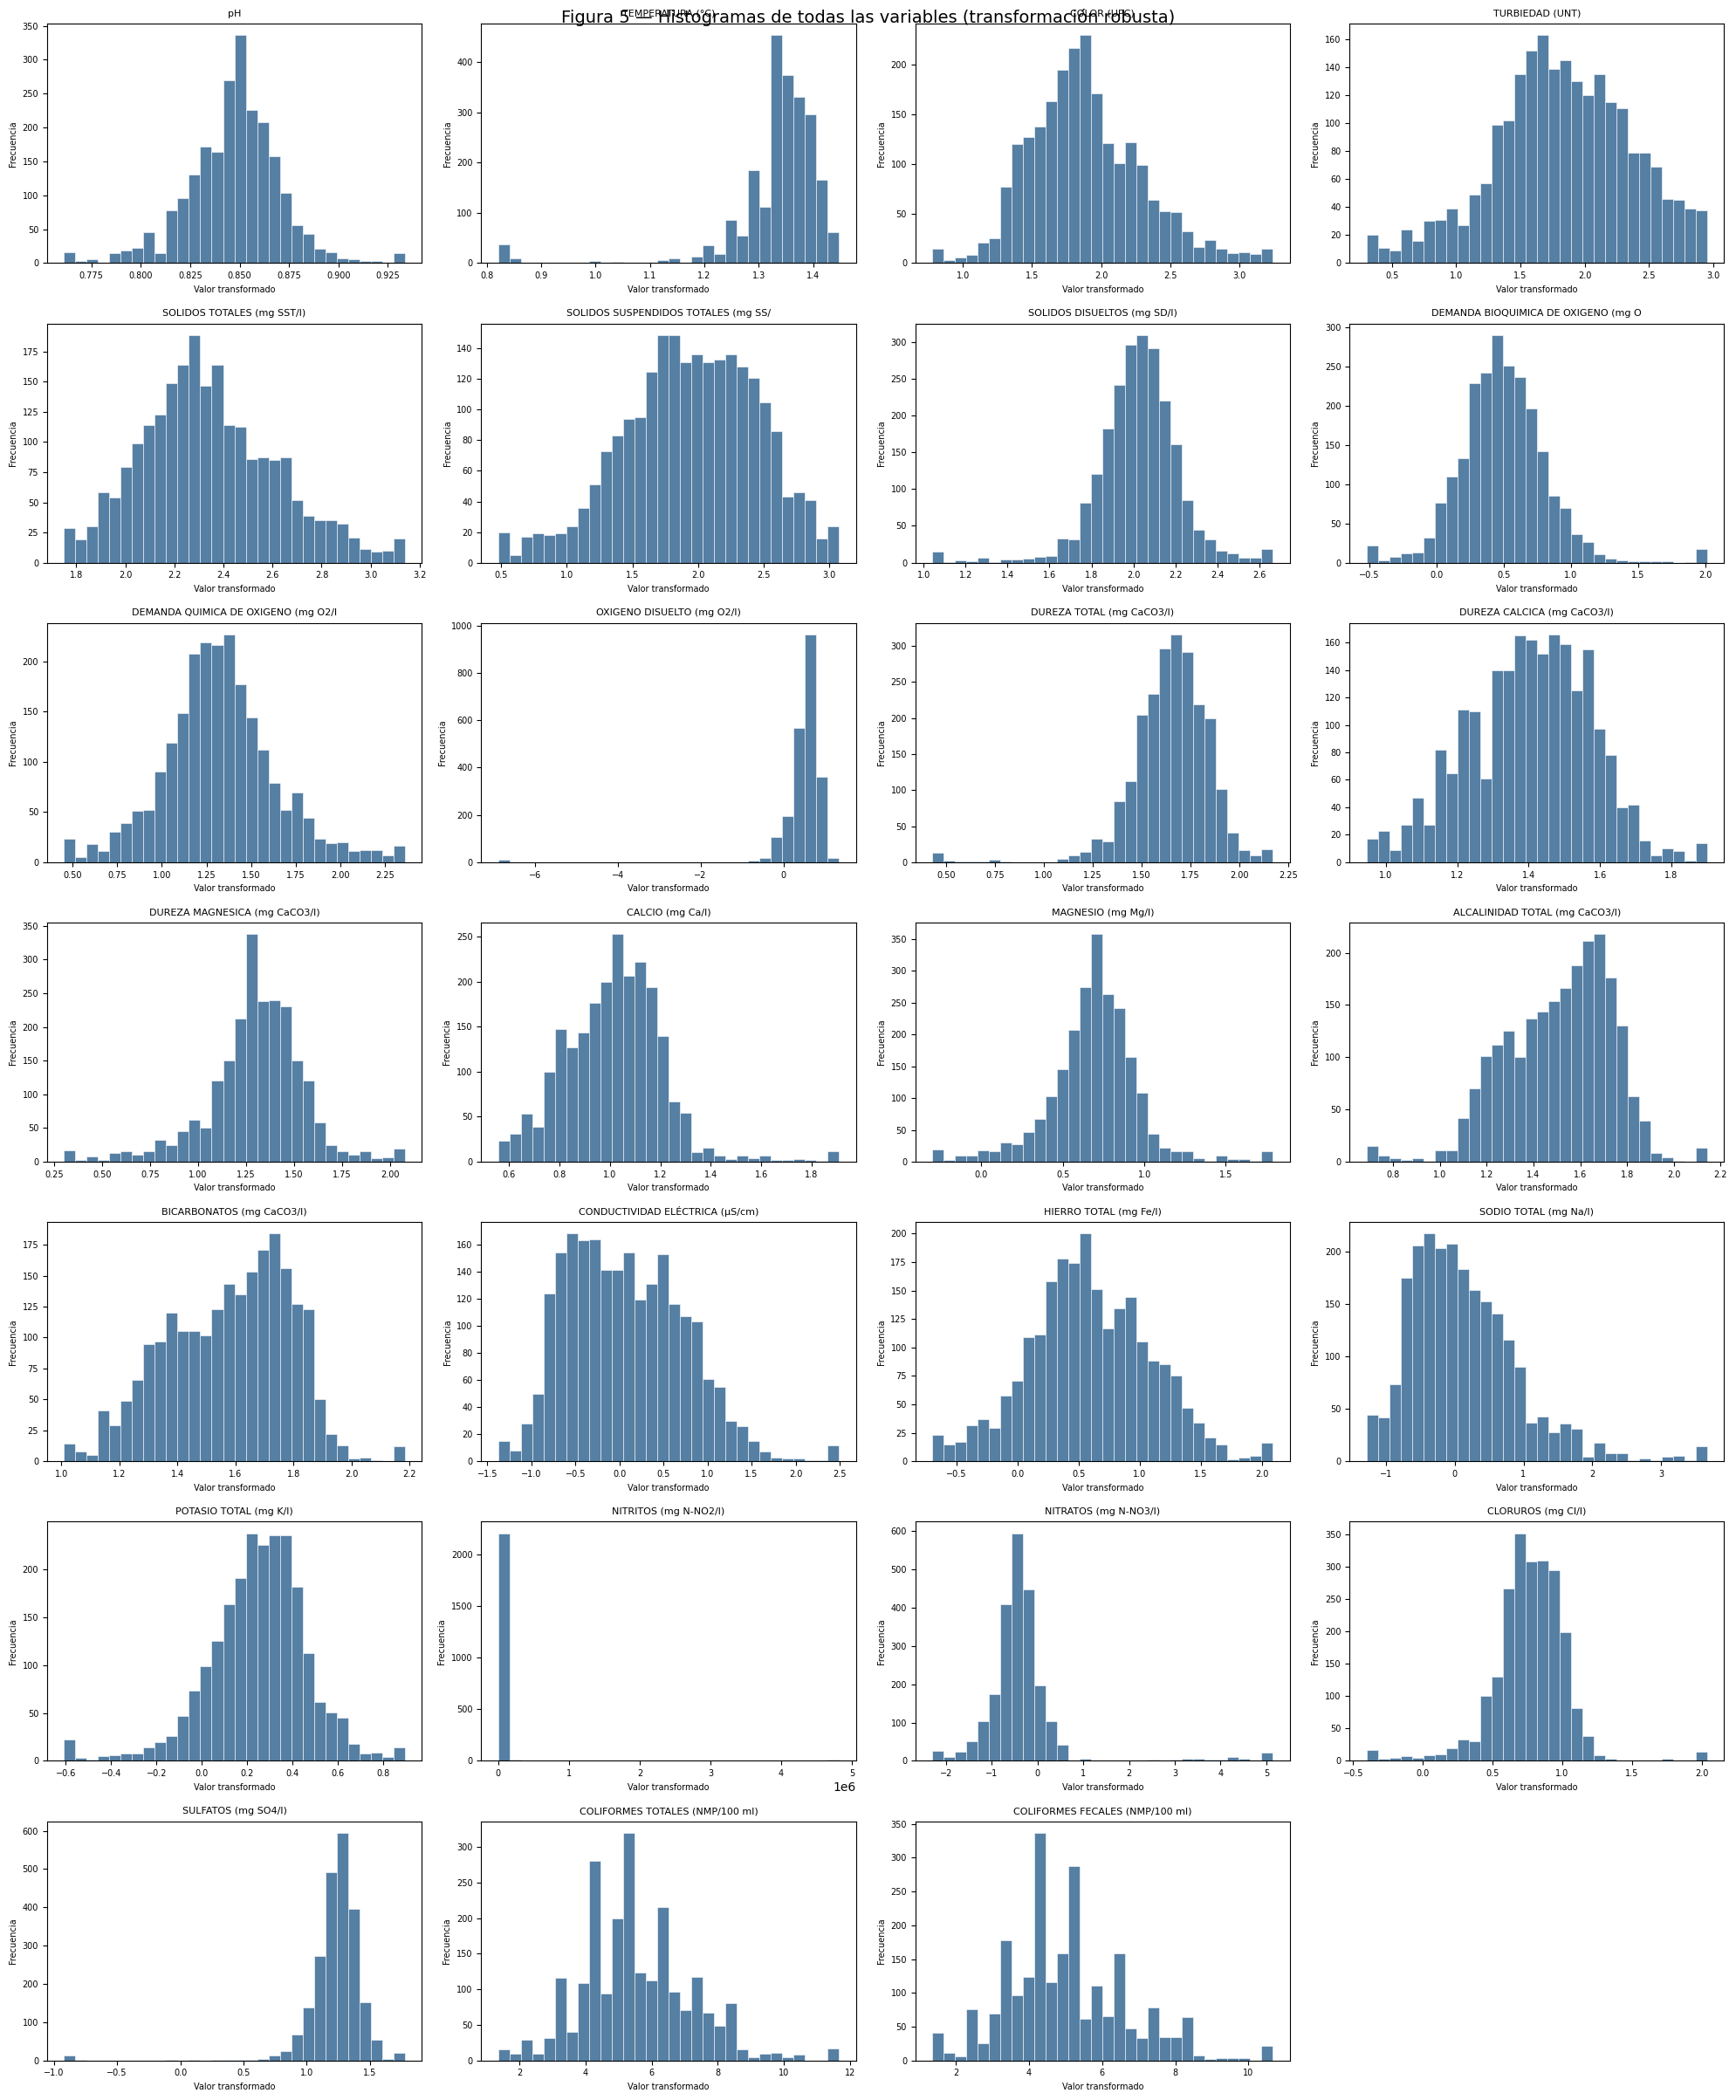

In [24]:
# Figura 5 — Histogramas de variables principales (todas las variables)
todas_vars = df_imputed.columns.tolist()
n_cols = 4
n_rows = int(np.ceil(len(todas_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(todas_vars):
    datos = transform_robusta_para_plot(df_imputed[col])
    axes[i].hist(datos, bins=30, color='#2C5F8D', alpha=0.8, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col[:35], fontsize=8)
    axes[i].set_xlabel('Valor transformado', fontsize=7)
    axes[i].set_ylabel('Frecuencia', fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Figura 5 — Histogramas de todas las variables (transformación robusta)', fontsize=14)
plt.tight_layout()
plt.show()

---
## SECCIÓN 5 — CORRELACIONES

In [25]:
# Separar predictores de objetivos para correlaciones
cols_pred_corr = [c for c in df_imputed.columns if c not in objetivos]
df_pred = df_imputed[cols_pred_corr]

corr_p = df_pred.corr(method='pearson')
corr_s = df_pred.corr(method='spearman')

def pares_fuertes(corr, umbral=0.8):
    pares = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            v = abs(corr.iloc[i, j])
            if v >= umbral:
                pares.append({'Var1': cols[i], 'Var2': cols[j], 'Correlación': round(corr.iloc[i, j], 4)})
    return pd.DataFrame(pares).sort_values('Correlación', key=abs, ascending=False)

pares_pearson = pares_fuertes(corr_p, 0.8)
pares_spearman = pares_fuertes(corr_s, 0.8)
print(f'Pares fuertes Pearson (≥0.8): {len(pares_pearson)}')
print(f'Pares fuertes Spearman (≥0.8): {len(pares_spearman)}')
display(pares_pearson.head(10))
display(pares_spearman.head(10))

Pares fuertes Pearson (≥0.8): 4
Pares fuertes Spearman (≥0.8): 7


,Var1,Var2,Correlación
3,NITRITOS (mg N-NO2/l),NITRATOS (mg N-NO3/l),0.9992
0,SOLIDOS TOTALES (mg SST/l),SOLIDOS SUSPENDIDOS TOTALES (mg SS/l),0.9459
2,CALCIO (mg Ca/l),MAGNESIO (mg Mg/l),0.8898
1,DUREZA MAGNESICA (mg CaCO3/l),MAGNESIO (mg Mg/l),0.8623


,Var1,Var2,Correlación
4,DUREZA MAGNESICA (mg CaCO3/l),MAGNESIO (mg Mg/l),0.9892
3,DUREZA CALCICA (mg CaCO3/l),CALCIO (mg Ca/l),0.9597
5,ALCALINIDAD TOTAL (mg CaCO3/l),BICARBONATOS (mg CaCO3/l),0.9332
6,COLIFORMES TOTALES (NMP/100 ml),COLIFORMES FECALES (NMP/100 ml),0.8907
0,SOLIDOS TOTALES (mg SST/l),SOLIDOS SUSPENDIDOS TOTALES (mg SS/l),0.8637
1,DUREZA TOTAL (mg CaCO3/l),DUREZA CALCICA (mg CaCO3/l),0.8178
2,DUREZA TOTAL (mg CaCO3/l),DUREZA MAGNESICA (mg CaCO3/l),0.8040


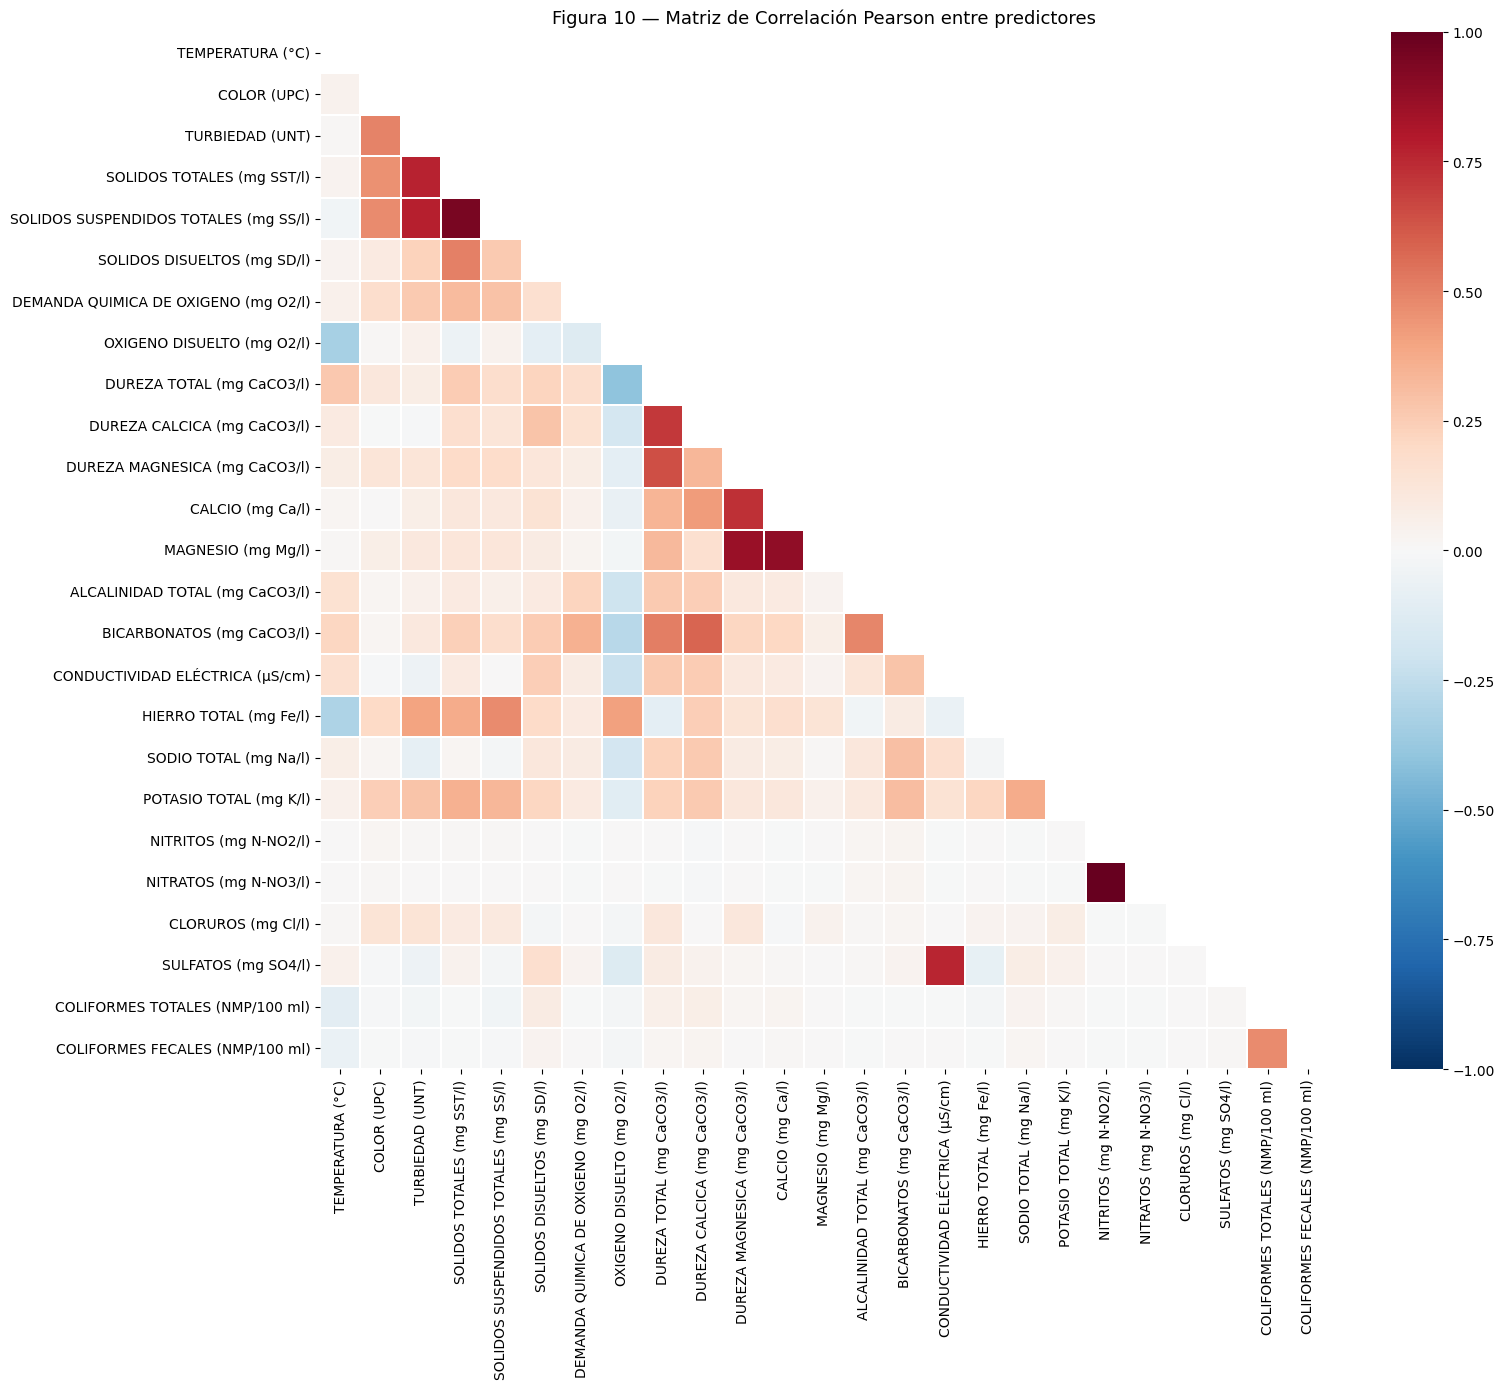

In [26]:
# Figura 10 — Heatmap Pearson (triángulo inferior)
mask_p = np.triu(np.ones_like(corr_p, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_p, mask=mask_p, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3)
ax.set_title('Figura 10 — Matriz de Correlación Pearson entre predictores', fontsize=13)
plt.tight_layout()
plt.show()

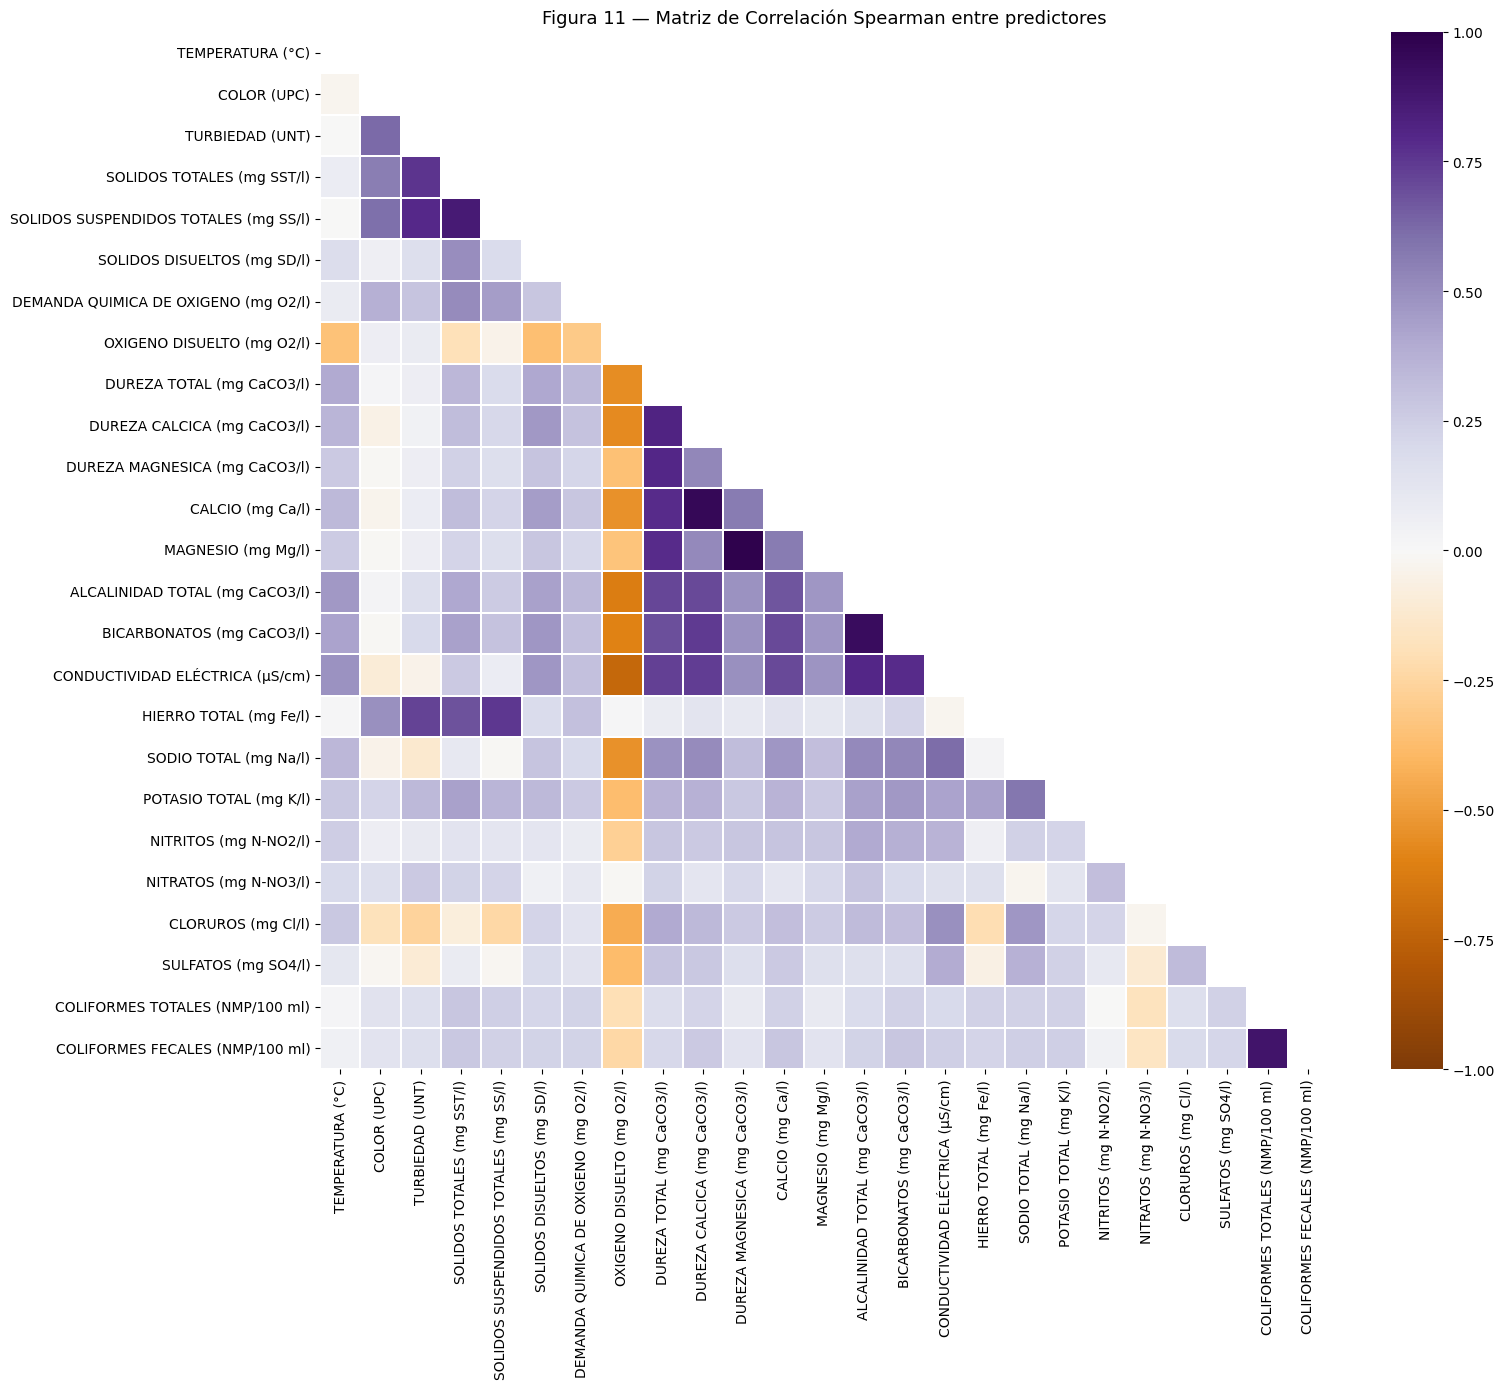

In [27]:
# Figura 11 — Heatmap Spearman (triángulo inferior)
mask_s = np.triu(np.ones_like(corr_s, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_s, mask=mask_s, annot=False, cmap='PuOr', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3)
ax.set_title('Figura 11 — Matriz de Correlación Spearman entre predictores', fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# Correlación Spearman predictor vs cada objetivo
corr_vs_obj = {}
for obj in objetivos:
    corrs = {}
    for col in cols_pred_corr:
        tmp = df_imputed[[col, obj]].dropna()
        r, _ = spearmanr(tmp[col], tmp[obj])
        corrs[col] = round(r, 4)
    corr_vs_obj[obj] = pd.Series(corrs).sort_values(key=abs, ascending=False)

print('\nTop 10 predictores por |Spearman| con DBO:')
display(corr_vs_obj[OBJ_DBO].head(10).to_frame('Spearman_DBO'))
print('\nTop 10 predictores por |Spearman| con pH:')
display(corr_vs_obj[OBJ_PH].head(10).to_frame('Spearman_pH'))


Top 10 predictores por |Spearman| con DBO:


,Spearman_DBO
BICARBONATOS (mg CaCO3/l),0.5269
CONDUCTIVIDAD ELÉCTRICA (µS/cm),0.5007
OXIGENO DISUELTO (mg O2/l),-0.4975
ALCALINIDAD TOTAL (mg CaCO3/l),0.4884
CALCIO (mg Ca/l),0.4608
DUREZA CALCICA (mg CaCO3/l),0.4584
SODIO TOTAL (mg Na/l),0.3813
DUREZA TOTAL (mg CaCO3/l),0.3575
COLIFORMES FECALES (NMP/100 ml),0.3548
POTASIO TOTAL (mg K/l),0.3360



Top 10 predictores por |Spearman| con pH:


,Spearman_pH
NITRATOS (mg N-NO3/l),0.3060
ALCALINIDAD TOTAL (mg CaCO3/l),0.2852
BICARBONATOS (mg CaCO3/l),0.2433
TEMPERATURA (°C),0.2354
DUREZA CALCICA (mg CaCO3/l),0.1725
NITRITOS (mg N-NO2/l),0.1703
CALCIO (mg Ca/l),0.1640
CONDUCTIVIDAD ELÉCTRICA (µS/cm),0.1583
DUREZA TOTAL (mg CaCO3/l),0.1534
SULFATOS (mg SO4/l),-0.1481


In [29]:
# Filtro Spearman colinealidad (umbral 0.85)
UMBRAL_SPEARMAN = 0.85
eliminar = []
cols_activas = list(cols_pred_corr)

# Calcular relevancia de cada variable con los objetivos
relevancia = {}
for col in cols_activas:
    r_dbo = abs(corr_vs_obj[OBJ_DBO].get(col, 0))
    r_ph  = abs(corr_vs_obj[OBJ_PH].get(col, 0))
    relevancia[col] = max(r_dbo, r_ph)

pares_altos = pares_fuertes(corr_s, UMBRAL_SPEARMAN)

for _, row in pares_altos.iterrows():
    v1, v2 = row['Var1'], row['Var2']
    if v1 in eliminar or v2 in eliminar:
        continue
    rel1, rel2 = relevancia.get(v1, 0), relevancia.get(v2, 0)
    if rel1 >= rel2:
        eliminar.append(v2)
    else:
        eliminar.append(v1)

cols_corr_ok = [c for c in cols_activas if c not in eliminar]
df_corr_filtered = df_imputed[cols_corr_ok + objetivos].copy()
print(f'Variables eliminadas por Spearman colinealidad: {len(eliminar)}')
print(f'Variables conservadas: {len(cols_corr_ok)}')
print('Eliminadas:', eliminar)

Variables eliminadas por Spearman colinealidad: 5
Variables conservadas: 20
Eliminadas: ['DUREZA MAGNESICA (mg CaCO3/l)', 'DUREZA CALCICA (mg CaCO3/l)', 'ALCALINIDAD TOTAL (mg CaCO3/l)', 'COLIFORMES TOTALES (NMP/100 ml)', 'SOLIDOS SUSPENDIDOS TOTALES (mg SS/l)']


---
## SECCIÓN 6 — VIF ITERATIVO

In [30]:
UMBRAL_VIF = 10.0

def calcular_vif(df_vars):
    """Calcula VIF para cada columna del DataFrame."""
    X_arr = df_vars.values.astype(float)
    vifs = {
        df_vars.columns[i]: variance_inflation_factor(X_arr, i)
        for i in range(X_arr.shape[1])
    }
    return pd.Series(vifs).sort_values(ascending=False)

cols_vif = [c for c in df_corr_filtered.columns if c not in objetivos]
df_vif_work = df_corr_filtered[cols_vif].copy()

historial_vif = []
iteracion = 0

while True:
    vifs = calcular_vif(df_vif_work)
    max_vif = vifs.iloc[0]
    max_var = vifs.index[0]
    if max_vif <= UMBRAL_VIF:
        break
    historial_vif.append({'Iteración': iteracion + 1, 'Variable eliminada': max_var, 'VIF': round(max_vif, 2)})
    df_vif_work = df_vif_work.drop(columns=[max_var])
    iteracion += 1

cols_vif_ok = df_vif_work.columns.tolist()
df_vif_filtered = df_imputed[cols_vif_ok + objetivos].copy()

print(f'Iteraciones VIF: {iteracion}')
print(f'Variables conservadas: {len(cols_vif_ok)}')
print(f'Variables eliminadas: {iteracion}')

print('\n--- Historial de eliminaciones VIF ---')
display(pd.DataFrame(historial_vif))

print('\n--- VIF final de variables conservadas ---')
vif_final = calcular_vif(df_vif_work).reset_index()
vif_final.columns = ['Variable', 'VIF']
vif_final['VIF'] = vif_final['VIF'].round(2)
display(vif_final)

Iteraciones VIF: 1
Variables conservadas: 19
Variables eliminadas: 1

--- Historial de eliminaciones VIF ---


,Iteración,Variable eliminada,VIF
0,1,NITRITOS (mg N-NO2/l),616.89



--- VIF final de variables conservadas ---


,Variable,VIF
0,CALCIO (mg Ca/l),5.69
1,MAGNESIO (mg Mg/l),5.62
2,SOLIDOS TOTALES (mg SST/l),3.82
3,TURBIEDAD (UNT),3.09
4,CONDUCTIVIDAD ELÉCTRICA (µS/cm),2.93
5,SULFATOS (mg SO4/l),2.57
6,BICARBONATOS (mg CaCO3/l),1.97
7,DUREZA TOTAL (mg CaCO3/l),1.85
8,HIERRO TOTAL (mg Fe/l),1.77
9,SOLIDOS DISUELTOS (mg SD/l),1.54


---
## SECCIÓN 7 — RFE (Eliminación Recursiva de Características)

In [32]:
def rfe_ensemble_para(objetivo, df_base, top_n_spearman=20):
    """
    Ejecuta ensemble RFE con 3 modelos (Linear, Ridge, SVR-linear).
    Escala X manualmente antes de RFE para evitar el error de coef_ en Pipeline.
    """
    cols_disp = [c for c in df_base.columns if c not in objetivos]
    tmp = df_base[cols_disp + [objetivo]].dropna()
    X_r = tmp[cols_disp]
    y_r = tmp[objetivo]

    # Pre-selección top-N por Spearman
    if len(cols_disp) > top_n_spearman:
        corrs_sp = {c: abs(spearmanr(X_r[c], y_r)[0]) for c in cols_disp}
        top_cols = sorted(corrs_sp, key=corrs_sp.get, reverse=True)[:top_n_spearman]
        X_r = X_r[top_cols]
        cols_disp = top_cols

    p = X_r.shape[1]
    k_final = max(5, int(sqrt(p)))

    # Scaler + modelo separados: RFE recibe solo el modelo (tiene coef_ directo)
    estimadores = [
        ('RFE-Linear', StandardScaler(), LinearRegression()),
        ('RFE-Ridge',  StandardScaler(), Ridge(alpha=1.0)),
        ('RFE-SVRlin', MinMaxScaler(),   SVR(kernel='linear', C=2.0))
    ]

    votos = {c: 0 for c in cols_disp}
    for nombre, scaler_rfe, modelo_rfe in estimadores:
        X_scaled = scaler_rfe.fit_transform(X_r)
        X_scaled_df = pd.DataFrame(X_scaled, columns=cols_disp)

        rfe = RFE(estimator=modelo_rfe, n_features_to_select=k_final, step=2)
        rfe.fit(X_scaled_df, y_r)

        seleccionadas = [c for c, s in zip(cols_disp, rfe.support_) if s]
        for c in seleccionadas:
            votos[c] += 1
        print(f'  [{nombre}] {len(seleccionadas)} vars seleccionadas')

    seleccion_mayoria = [c for c, v in votos.items() if v >= 2]
    if len(seleccion_mayoria) < 5:
        seleccion_mayoria = sorted(votos, key=votos.get, reverse=True)[:k_final]

    tabla_votos = pd.DataFrame({
        'Variable': list(votos.keys()),
        'Votos': list(votos.values())
    }).sort_values('Votos', ascending=False)
    tabla_votos['Seleccionada'] = tabla_votos['Variable'].isin(seleccion_mayoria).map({True: 'Sí', False: 'No'})

    return {
        'seleccion_mayoria': sorted(seleccion_mayoria),
        'votos': votos,
        'tabla': tabla_votos,
        'k_final': k_final
    }

print('Ejecutando RFE para DBO...')
rfe_resultados = {}
rfe_resultados[OBJ_DBO] = rfe_ensemble_para(OBJ_DBO, df_vif_filtered)

print(f'\nRFE-DBO selección ({len(rfe_resultados[OBJ_DBO]["seleccion_mayoria"])} vars):')
print(rfe_resultados[OBJ_DBO]['seleccion_mayoria'])

Ejecutando RFE para DBO...
  [RFE-Linear] 5 vars seleccionadas
  [RFE-Ridge] 5 vars seleccionadas
  [RFE-SVRlin] 5 vars seleccionadas

RFE-DBO selección (5 vars):
['CALCIO (mg Ca/l)', 'HIERRO TOTAL (mg Fe/l)', 'MAGNESIO (mg Mg/l)', 'SOLIDOS TOTALES (mg SST/l)', 'TURBIEDAD (UNT)']


In [33]:
print('Ejecutando RFE para pH...')
rfe_resultados[OBJ_PH] = rfe_ensemble_para(OBJ_PH, df_vif_filtered)

print(f'\nRFE-pH selección ({len(rfe_resultados[OBJ_PH]["seleccion_mayoria"])} vars):')
print(rfe_resultados[OBJ_PH]['seleccion_mayoria'])

Ejecutando RFE para pH...
  [RFE-Linear] 5 vars seleccionadas
  [RFE-Ridge] 5 vars seleccionadas
  [RFE-SVRlin] 5 vars seleccionadas

RFE-pH selección (5 vars):
['BICARBONATOS (mg CaCO3/l)', 'CONDUCTIVIDAD ELÉCTRICA (µS/cm)', 'POTASIO TOTAL (mg K/l)', 'SULFATOS (mg SO4/l)', 'TEMPERATURA (°C)']


In [34]:
# Tablas RFE por objetivo
print('=== Tabla de votos RFE — DBO ===')
display(rfe_resultados[OBJ_DBO]['tabla'])

print('\n=== Tabla de votos RFE — pH ===')
display(rfe_resultados[OBJ_PH]['tabla'])

=== Tabla de votos RFE — DBO ===


,Variable,Votos,Seleccionada
8,CALCIO (mg Ca/l),3,Sí
12,HIERRO TOTAL (mg Fe/l),3,Sí
2,TURBIEDAD (UNT),2,Sí
9,MAGNESIO (mg Mg/l),2,Sí
3,SOLIDOS TOTALES (mg SST/l),2,Sí
10,BICARBONATOS (mg CaCO3/l),1,No
6,OXIGENO DISUELTO (mg O2/l),1,No
5,DEMANDA QUIMICA DE OXIGENO (mg O2/l),1,No
0,TEMPERATURA (°C),0,No
1,COLOR (UPC),0,No



=== Tabla de votos RFE — pH ===


,Variable,Votos,Seleccionada
14,POTASIO TOTAL (mg K/l),3,Sí
17,SULFATOS (mg SO4/l),3,Sí
10,BICARBONATOS (mg CaCO3/l),3,Sí
11,CONDUCTIVIDAD ELÉCTRICA (µS/cm),3,Sí
0,TEMPERATURA (°C),2,Sí
6,OXIGENO DISUELTO (mg O2/l),1,No
1,COLOR (UPC),0,No
2,TURBIEDAD (UNT),0,No
5,DEMANDA QUIMICA DE OXIGENO (mg O2/l),0,No
4,SOLIDOS DISUELTOS (mg SD/l),0,No


In [35]:
# Unión RFE (intersección; si < 5, usar unión)
rfe_comun = sorted(
    set(rfe_resultados[OBJ_DBO]['seleccion_mayoria']) &
    set(rfe_resultados[OBJ_PH]['seleccion_mayoria'])
)
if len(rfe_comun) < 5:
    rfe_comun = sorted(
        set(rfe_resultados[OBJ_DBO]['seleccion_mayoria']) |
        set(rfe_resultados[OBJ_PH]['seleccion_mayoria'])
    )

print(f'Variables RFE-comun ({len(rfe_comun)}): {rfe_comun}')

# Definición de escenarios de features
ESCENARIOS_VARS = {
    'vif':      [c for c in df_vif_filtered.columns if c not in objetivos],
    'rfe_dbo':  rfe_resultados[OBJ_DBO]['seleccion_mayoria'],
    'rfe_ph':   rfe_resultados[OBJ_PH]['seleccion_mayoria'],
    'rfe_comun': rfe_comun
}

for k, v in ESCENARIOS_VARS.items():
    print(f'{k}: {len(v)} variables')

Variables RFE-comun (10): ['BICARBONATOS (mg CaCO3/l)', 'CALCIO (mg Ca/l)', 'CONDUCTIVIDAD ELÉCTRICA (µS/cm)', 'HIERRO TOTAL (mg Fe/l)', 'MAGNESIO (mg Mg/l)', 'POTASIO TOTAL (mg K/l)', 'SOLIDOS TOTALES (mg SST/l)', 'SULFATOS (mg SO4/l)', 'TEMPERATURA (°C)', 'TURBIEDAD (UNT)']
vif: 19 variables
rfe_dbo: 5 variables
rfe_ph: 5 variables
rfe_comun: 10 variables


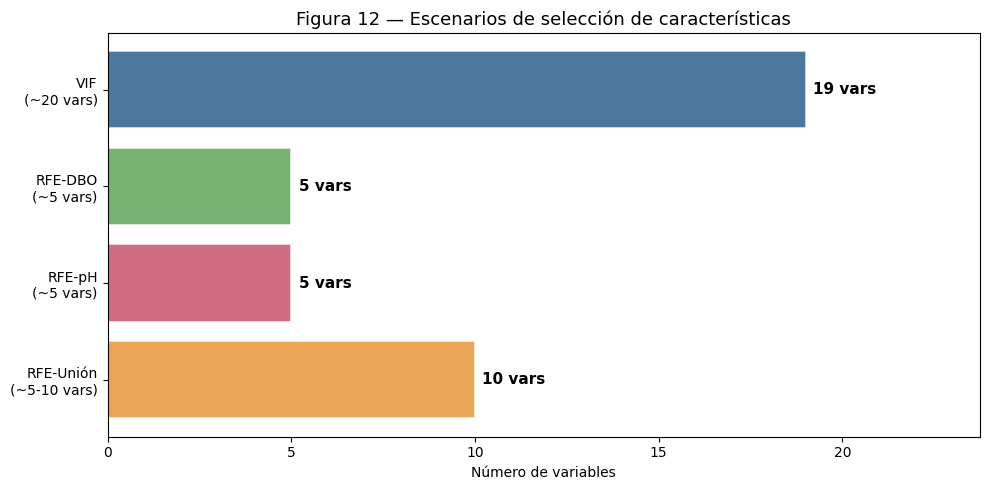

In [36]:
# Figura 12 — Diagrama de escenarios de features
fig, ax = plt.subplots(figsize=(10, 5))
nombres = ['VIF\n(~20 vars)', 'RFE-DBO\n(~5 vars)', 'RFE-pH\n(~5 vars)', 'RFE-Unión\n(~5-10 vars)']
n_vars = [len(ESCENARIOS_VARS[k]) for k in ['vif', 'rfe_dbo', 'rfe_ph', 'rfe_comun']]
colores = ['#2C5F8D', '#5FA55A', '#C9546C', '#E8963A']

bars = ax.barh(nombres, n_vars, color=colores, alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, n in zip(bars, n_vars):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{n} vars', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Número de variables')
ax.set_title('Figura 12 — Escenarios de selección de características', fontsize=13)
ax.set_xlim(0, max(n_vars) * 1.25)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## SECCIÓN 8 — ENTRENAMIENTO BASE (6 modelos × 4 escenarios × 2 objetivos)

In [37]:
# Configuración global
rng = 42
TEST_SIZE = 0.20
CV = RepeatedKFold(n_splits=5, n_repeats=3, random_state=rng)
ESCENARIOS = ['vif', 'rfe_dbo', 'rfe_ph', 'rfe_comun']
OBJETIVOS   = [OBJ_DBO, OBJ_PH]

def _metricas(y_true, y_pred):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, r2, mae

def get_modelos_base():
    return {
        'LR':        Pipeline([('std', StandardScaler()), ('m', LinearRegression())]),
        'CART':      DecisionTreeRegressor(random_state=42),
        'RF':        RandomForestRegressor(random_state=42, n_jobs=-1),
        'SVR (RBF)': Pipeline([('std', StandardScaler()), ('m', SVR(kernel='rbf'))]),
        'MLP':       Pipeline([('std', StandardScaler()), ('m', MLPRegressor(random_state=42, max_iter=600))]),
        'XGBoost':   xgb.XGBRegressor(
                        random_state=42, tree_method='hist', n_jobs=-1,
                        max_depth=6, learning_rate=0.1, n_estimators=400,
                        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                        verbosity=0
                    )
    }

print('Configuración lista. Iniciando entrenamiento base...')

Configuración lista. Iniciando entrenamiento base...


In [38]:
resultados_base = []
modelos_base    = {}
splits_base     = {}

for obj in OBJETIVOS:
    obj_corto = 'DBO' if 'BIOQUIMICA' in obj else 'pH'
    for esc in ESCENARIOS:
        vars_esc = ESCENARIOS_VARS[esc]
        vars_disp = [v for v in vars_esc if v in df_imputed.columns]
        tmp = df_imputed[vars_disp + [obj]].dropna()
        X_e = tmp[vars_disp]
        y_e = tmp[obj]

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_e, y_e, test_size=TEST_SIZE, random_state=42, shuffle=True
        )
        splits_base[(obj, esc)] = (X_tr, X_te, y_tr, y_te)

        modelos_iter = get_modelos_base()
        for nombre_m, modelo in modelos_iter.items():
            t0 = time.time()
            modelo.fit(X_tr, y_tr)
            y_pred = modelo.predict(X_te)
            rmse, r2, mae = _metricas(y_te, y_pred)
            elapsed = round(time.time() - t0, 2)

            clave = f'{nombre_m}_{obj_corto}_{esc}_base'
            modelos_base[clave] = modelo
            resultados_base.append({
                'objetivo': obj_corto,
                'escenario': esc,
                'modelo': nombre_m,
                'R2': round(r2, 4),
                'RMSE': round(rmse, 4),
                'MAE': round(mae, 4),
                'n_vars': len(vars_disp),
                'tiempo_s': elapsed
            })
            print(f'  [{obj_corto}|{esc}|{nombre_m}] R²={r2:.3f} RMSE={rmse:.3f} ({elapsed}s)')

artefactos['resumen_global_4esc'] = pd.DataFrame(resultados_base)
artefactos['modelos_base']        = modelos_base
artefactos['splits']              = splits_base
print('\nEntrenamiento base completado.')
print(f'Total combinaciones: {len(resultados_base)}')

  [DBO|vif|LR] R²=0.533 RMSE=7.237 (0.01s)
  [DBO|vif|CART] R²=-0.651 RMSE=13.599 (0.04s)
  [DBO|vif|RF] R²=0.149 RMSE=9.766 (0.4s)
  [DBO|vif|SVR (RBF)] R²=0.070 RMSE=10.209 (0.13s)
  [DBO|vif|MLP] R²=0.779 RMSE=4.970 (1.33s)
  [DBO|vif|XGBoost] R²=0.281 RMSE=8.973 (1.47s)
  [DBO|rfe_dbo|LR] R²=0.538 RMSE=7.198 (0.01s)
  [DBO|rfe_dbo|CART] R²=-2.312 RMSE=19.261 (0.01s)
  [DBO|rfe_dbo|RF] R²=-0.448 RMSE=12.738 (0.22s)
  [DBO|rfe_dbo|SVR (RBF)] R²=0.049 RMSE=10.319 (0.1s)
  [DBO|rfe_dbo|MLP] R²=0.698 RMSE=5.816 (0.47s)
  [DBO|rfe_dbo|XGBoost] R²=-0.554 RMSE=13.194 (0.52s)
  [DBO|rfe_ph|LR] R²=0.027 RMSE=10.440 (0.01s)
  [DBO|rfe_ph|CART] R²=-2.052 RMSE=18.491 (0.01s)
  [DBO|rfe_ph|RF] R²=0.825 RMSE=4.429 (0.22s)
  [DBO|rfe_ph|SVR (RBF)] R²=0.067 RMSE=10.221 (0.11s)
  [DBO|rfe_ph|MLP] R²=0.369 RMSE=8.406 (1.15s)
  [DBO|rfe_ph|XGBoost] R²=0.903 RMSE=3.301 (0.69s)
  [DBO|rfe_comun|LR] R²=0.530 RMSE=7.258 (0.01s)
  [DBO|rfe_comun|CART] R²=-0.653 RMSE=13.607 (0.02s)
  [DBO|rfe_comun|RF] R²=0

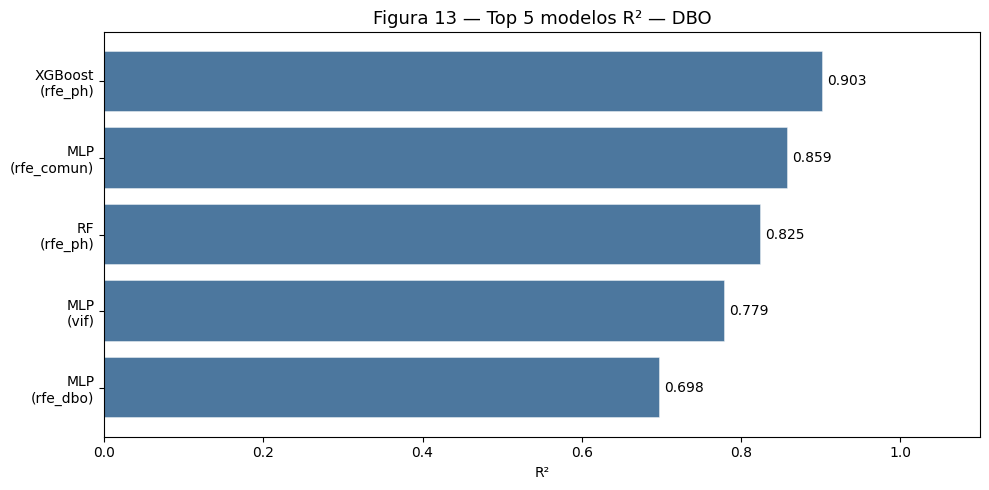

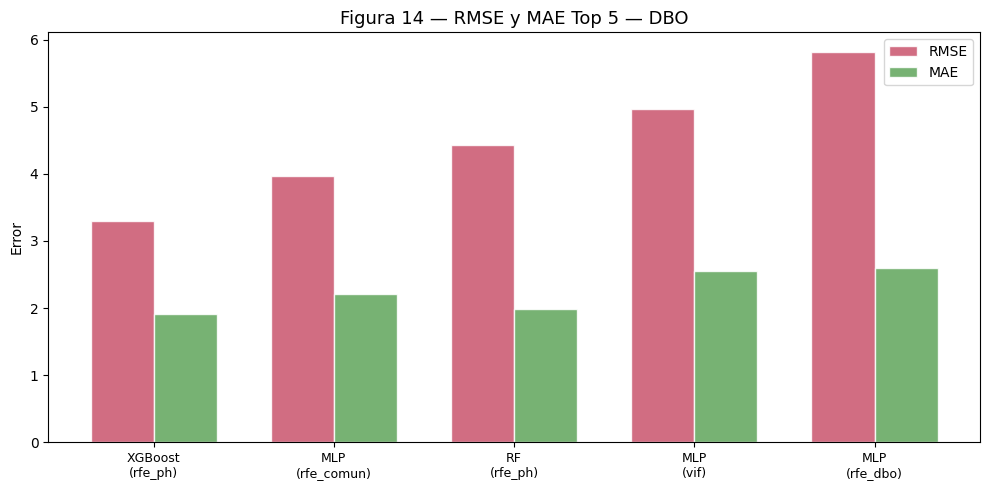

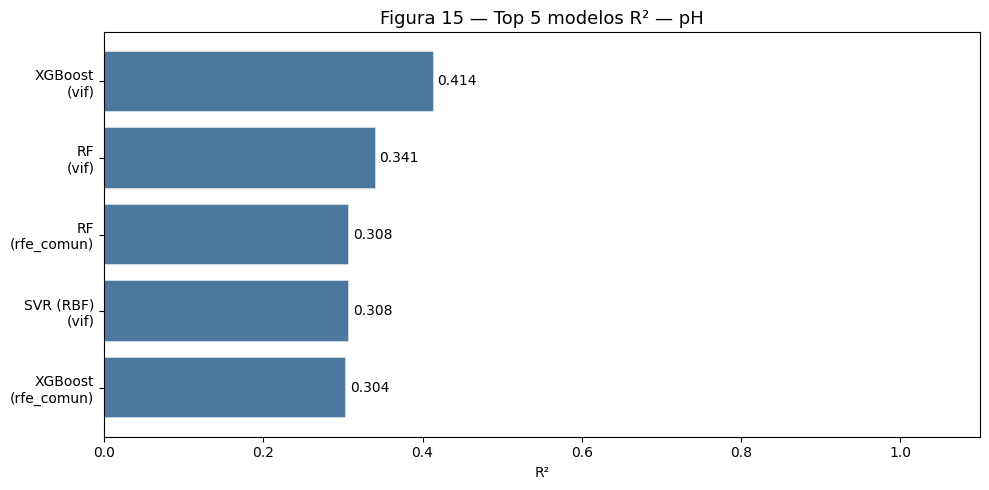

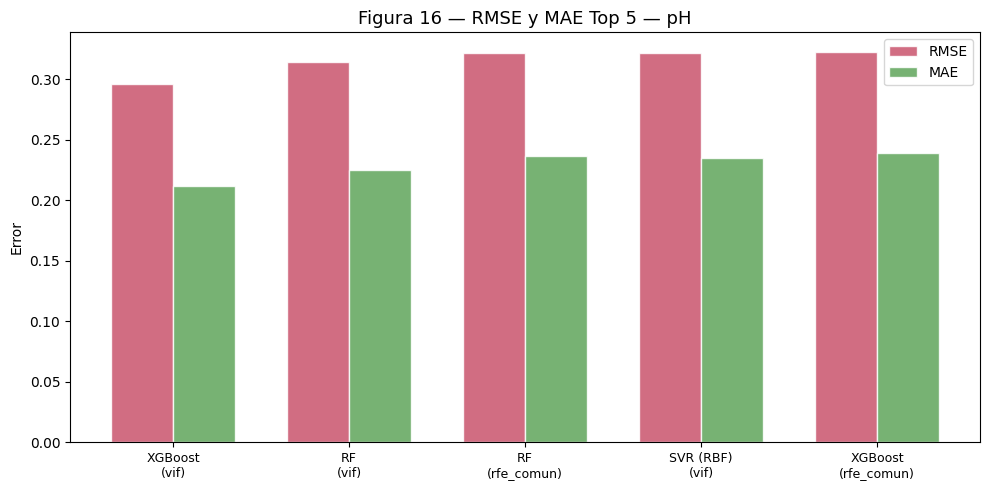

In [39]:
# Función para graficar top-5 modelos por R²
# Paleta elegante publicable
_PAL_R2   = ['#1B4F8A', '#2E72B8', '#4A90D9', '#6AAED6', '#92C5E8']  # azules degradados
_PAL_RMSE = '#C0392B'   # rojo vino
_PAL_MAE  = '#27AE60'   # verde esmeralda
_GREY_TXT = '#2C3E50'   # gris oscuro para texto sobre blanco

def graficar_top5(df_res, objetivo_corto, fig_r2_num, fig_err_num):
    df_obj = df_res[df_res['objetivo'] == objetivo_corto].copy()
    df_top = df_obj.nlargest(5, 'R2').reset_index(drop=True)
    etiquetas = [f"{r['modelo']}\n({r['escenario']})" for _, r in df_top.iterrows()]

    # ── Figura R² ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#F7F9FC')

    bars = ax.barh(etiquetas, df_top['R2'],
                   color=_PAL_R2[:len(df_top)],
                   edgecolor='white', linewidth=1.4,
                   height=0.55)

    for bar, v in zip(bars, df_top['R2']):
        ax.text(bar.get_width() - 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}',
                va='center', ha='right',
                fontsize=10.5, fontweight='bold',
                color='white')

    ax.set_xlabel('Coeficiente de determinación (R²)', fontsize=11, color=_GREY_TXT)
    ax.set_xlim(0, 1.08)
    ax.set_title(f'Figura {fig_r2_num} — Top 5 modelos por R² — {objetivo_corto}',
                 fontsize=13, fontweight='bold', color=_GREY_TXT, pad=12)
    ax.invert_yaxis()
    ax.tick_params(axis='both', labelsize=10, colors=_GREY_TXT)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#BDC3C7')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    # ── Figura RMSE / MAE con números ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#F7F9FC')

    x = np.arange(len(etiquetas))
    w = 0.32

    bars_rmse = ax.bar(x - w/2, df_top['RMSE'], w,
                       label='RMSE', color=_PAL_RMSE, alpha=0.88,
                       edgecolor='white', linewidth=1.2)
    bars_mae  = ax.bar(x + w/2, df_top['MAE'],  w,
                       label='MAE',  color=_PAL_MAE,  alpha=0.88,
                       edgecolor='white', linewidth=1.2)

    # Números sobre cada barra
    for bar in bars_rmse:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=_PAL_RMSE)

    for bar in bars_mae:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                f'{h:.3f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=_PAL_MAE)

    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, fontsize=9, color=_GREY_TXT)
    ax.set_ylabel('Error', fontsize=11, color=_GREY_TXT)
    ax.set_title(f'Figura {fig_err_num} — RMSE y MAE Top 5 — {objetivo_corto}',
                 fontsize=13, fontweight='bold', color=_GREY_TXT, pad=12)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.tick_params(axis='y', labelsize=10, colors=_GREY_TXT)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#BDC3C7')
    ax.set_axisbelow(True)
    # Ampliar eje Y para que los números no queden cortados
    y_max = max(df_top['RMSE'].max(), df_top['MAE'].max())
    ax.set_ylim(0, y_max * 1.18)
    plt.tight_layout()
    plt.show()

df_base = artefactos['resumen_global_4esc']
graficar_top5(df_base, 'DBO', 13, 14)
graficar_top5(df_base, 'pH',  15, 16)


---
## SECCIÓN 9 — GRID SEARCH (LR, CART, RF, SVR, MLP)

In [40]:
param_grids = {
    'LR': {
        'm__fit_intercept': [True, False]
    },
    'CART': {
        'max_depth':         [3, 5, 8, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4]
    },
    'RF': {
        'n_estimators':      [100, 300, 500],
        'max_depth':         [5, 10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf':  [1, 2],
        'max_features':      ['sqrt', 'log2', 0.5]
    },
    'SVR (RBF)': {
        'm__C':       [0.1, 1, 10, 100],
        'm__epsilon': [0.01, 0.1, 0.5],
        'm__gamma':   ['scale', 'auto']
    },
    'MLP': {
        'm__hidden_layer_sizes': [(50,), (100,), (100, 50), (200, 100)],
        'm__activation':         ['relu', 'tanh'],
        'm__alpha':              [0.0001, 0.001, 0.01],
        'm__learning_rate_init': [0.001, 0.01]
    }
}

print('Grids definidos para:', list(param_grids.keys()))

Grids definidos para: ['LR', 'CART', 'RF', 'SVR (RBF)', 'MLP']


In [44]:
def correr_publicacion():
    """
    Ejecuta Grid Search para LR, CART, RF, SVR (RBF), MLP.
    XGBoost se omite — va con Optuna en Sección 10.
    """
    import warnings
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
    warnings.filterwarnings('ignore')

    resultados_grid = []
    modelos_grid    = {}

    for obj in OBJETIVOS:
        obj_corto = 'DBO' if 'BIOQUIMICA' in obj else 'pH'
        for esc in ESCENARIOS:
            X_tr, X_te, y_tr, y_te = splits_base[(obj, esc)]

            for nombre_m, modelo_base in get_modelos_base().items():
                if nombre_m == 'XGBoost':
                    continue

                grid = param_grids.get(nombre_m, {})
                t0   = time.time()

                # MLP no hereda el filtro de warnings en workers paralelos
                # → usar n_jobs=1 solo para MLP
                n_jobs_gs = 1 if nombre_m == 'MLP' else -1

                if grid:
                    gs = GridSearchCV(
                        clone(modelo_base), grid,
                        cv=CV,
                        scoring='neg_mean_squared_error',
                        n_jobs=n_jobs_gs,
                        refit=True,
                        verbose=0,
                        error_score=0
                    )
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        gs.fit(X_tr, y_tr)
                    mejor       = gs.best_estimator_
                    best_params = gs.best_params_
                else:
                    mejor = clone(modelo_base)
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        mejor.fit(X_tr, y_tr)
                    best_params = {}

                y_pred        = mejor.predict(X_te)
                rmse, r2, mae = _metricas(y_te, y_pred)
                elapsed       = round(time.time() - t0, 2)

                clave = f'{nombre_m}_{obj_corto}_{esc}_grid'
                modelos_grid[clave] = mejor
                resultados_grid.append({
                    'objetivo':    obj_corto,
                    'escenario':   esc,
                    'modelo':      nombre_m,
                    'search':      'grid',
                    'R2':          round(r2,   4),
                    'RMSE':        round(rmse, 4),
                    'MAE':         round(mae,  4),
                    'best_params': str(best_params),
                    'tiempo_s':    elapsed
                })
                print(f'  [{obj_corto}|{esc}|{nombre_m}]  R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  ({elapsed}s)')

    artefactos['grid_summary_test'] = pd.DataFrame(resultados_grid)
    artefactos['modelos_grid']      = modelos_grid
    return artefactos['grid_summary_test']


print('Iniciando Grid Search (puede tardar 15-20 min)...')
t_inicio_grid = time.time()
df_grid = correr_publicacion()
print(f'\nGrid Search completado en {(time.time()-t_inicio_grid)/60:.1f} min')
display(df_grid.sort_values('R2', ascending=False).head(10))

Iniciando Grid Search (puede tardar 15-20 min)...
  [DBO|vif|LR]  R²=0.533  RMSE=7.237  MAE=3.753  (2.51s)
  [DBO|vif|CART]  R²=0.452  RMSE=7.839  MAE=2.270  (2.0s)
  [DBO|vif|RF]  R²=0.719  RMSE=5.615  MAE=1.981  (464.18s)
  [DBO|vif|SVR (RBF)]  R²=0.850  RMSE=4.100  MAE=1.740  (10.52s)
  [DBO|vif|MLP]  R²=0.785  RMSE=4.913  MAE=2.305  (2740.0s)
  [DBO|rfe_dbo|LR]  R²=0.538  RMSE=7.198  MAE=3.774  (2.22s)
  [DBO|rfe_dbo|CART]  R²=0.338  RMSE=8.613  MAE=2.518  (0.78s)
  [DBO|rfe_dbo|RF]  R²=0.634  RMSE=6.403  MAE=2.321  (264.09s)
  [DBO|rfe_dbo|SVR (RBF)]  R²=0.693  RMSE=5.862  MAE=2.076  (5.42s)
  [DBO|rfe_dbo|MLP]  R²=0.806  RMSE=4.661  MAE=2.448  (1343.04s)
  [DBO|rfe_ph|LR]  R²=0.027  RMSE=10.440  MAE=4.707  (1.73s)
  [DBO|rfe_ph|CART]  R²=0.865  RMSE=3.886  MAE=1.928  (0.77s)
  [DBO|rfe_ph|RF]  R²=0.898  RMSE=3.381  MAE=1.898  (241.52s)
  [DBO|rfe_ph|SVR (RBF)]  R²=0.668  RMSE=6.094  MAE=2.131  (5.58s)
  [DBO|rfe_ph|MLP]  R²=0.805  RMSE=4.669  MAE=2.233  (2104.79s)
  [DBO|rfe_comu

,objetivo,escenario,modelo,search,R2,RMSE,MAE,best_params,tiempo_s
12,DBO,rfe_ph,RF,grid,0.8979,3.3814,1.8981,"{'max_depth': 10, 'max_features': 'log2', 'min...",241.52
11,DBO,rfe_ph,CART,grid,0.8652,3.8863,1.9279,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",0.77
19,DBO,rfe_comun,MLP,grid,0.8599,3.9613,2.2526,"{'m__activation': 'tanh', 'm__alpha': 0.01, 'm...",1590.95
3,DBO,vif,SVR (RBF),grid,0.8499,4.0999,1.7397,"{'m__C': 100, 'm__epsilon': 0.5, 'm__gamma': '...",10.52
17,DBO,rfe_comun,RF,grid,0.8375,4.2672,1.9282,"{'max_depth': None, 'max_features': 'sqrt', 'm...",317.17
9,DBO,rfe_dbo,MLP,grid,0.8060,4.6612,2.4481,"{'m__activation': 'relu', 'm__alpha': 0.0001, ...",1343.04
14,DBO,rfe_ph,MLP,grid,0.8054,4.6693,2.2333,"{'m__activation': 'tanh', 'm__alpha': 0.0001, ...",2104.79
4,DBO,vif,MLP,grid,0.7845,4.9131,2.3049,"{'m__activation': 'tanh', 'm__alpha': 0.001, '...",2740.00
18,DBO,rfe_comun,SVR (RBF),grid,0.7650,5.1307,1.9297,"{'m__C': 100, 'm__epsilon': 0.01, 'm__gamma': ...",8.06
2,DBO,vif,RF,grid,0.7186,5.6147,1.9812,"{'max_depth': 10, 'max_features': 0.5, 'min_sa...",464.18


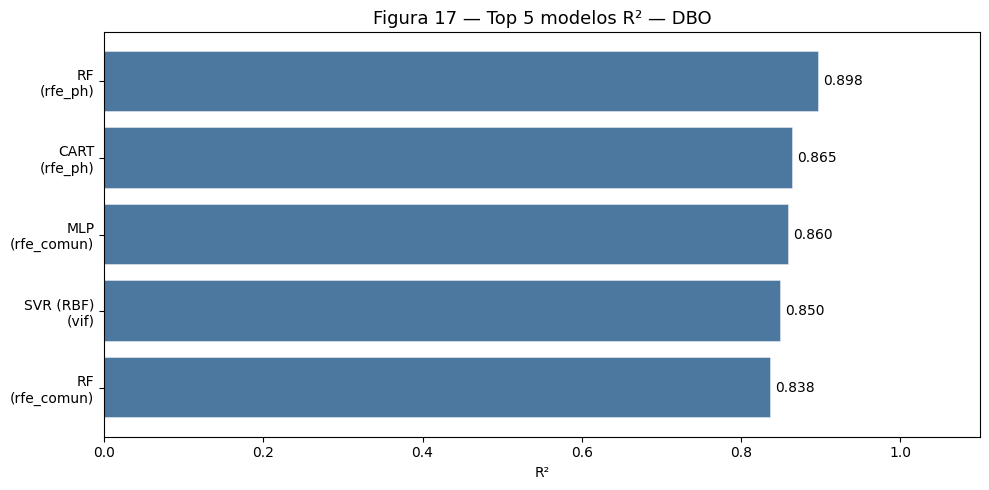

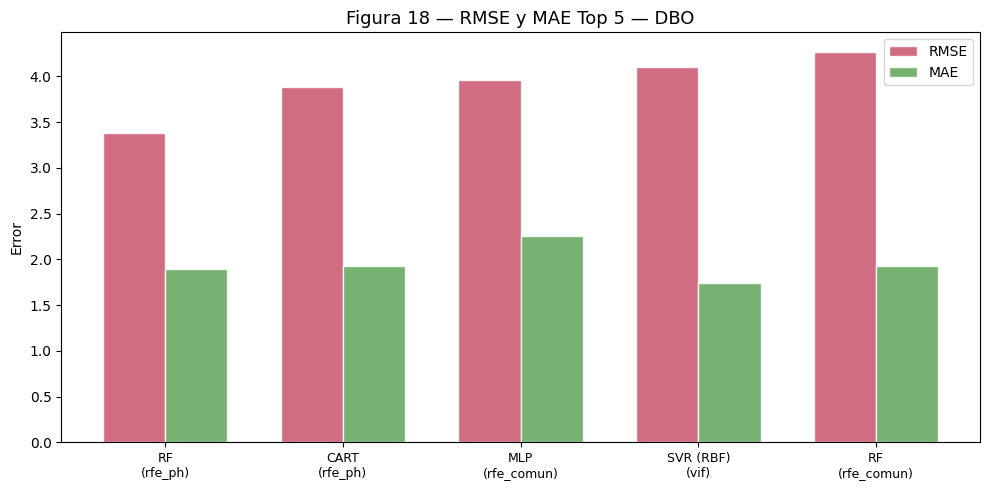

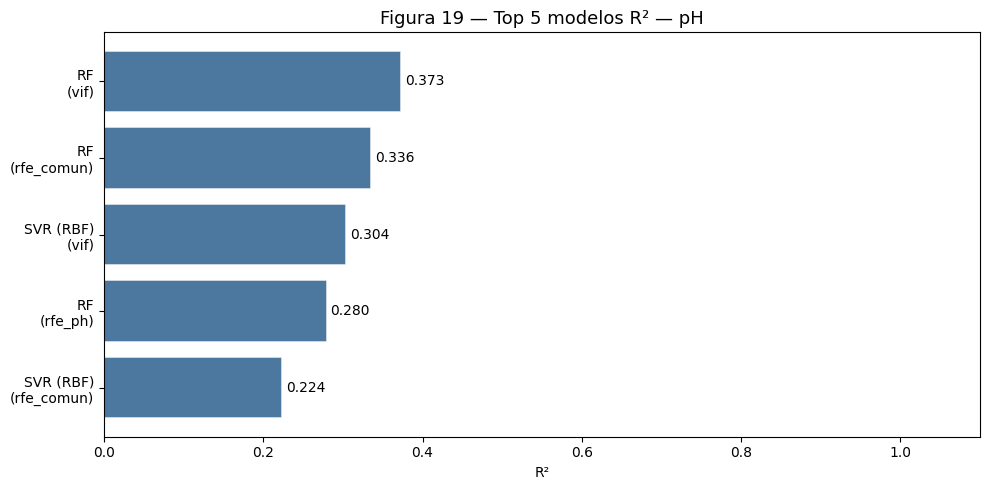

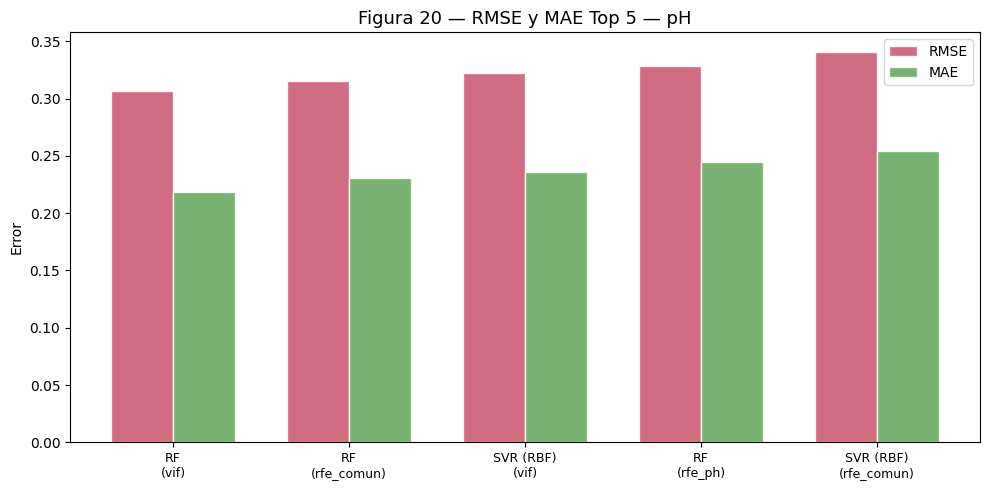

In [45]:
# Figuras 17-20 — Post Grid Search
graficar_top5(df_grid, 'DBO', 17, 18)
graficar_top5(df_grid, 'pH',  19, 20)

---
## SECCIÓN 10 — OPTUNA (solo XGBoost, 60 trials)

In [46]:
N_TRIALS = 60

def objective_xgb(trial, X_train, y_train, cv):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 2000),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1,
        'verbosity': 0
    }
    modelo = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        modelo, X_train, y_train,
        cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
    )
    return -scores.mean()


def correr_optuna_publicacion(n_trials=60):
    """Ejecuta Optuna para XGBoost en todas las combinaciones objetivo × escenario."""
    resultados_optuna = []
    modelos_optuna    = {}
    studies           = {}

    for obj in OBJETIVOS:
        obj_corto = 'DBO' if 'BIOQUIMICA' in obj else 'pH'
        for esc in ESCENARIOS:
            X_tr, X_te, y_tr, y_te = splits_base[(obj, esc)]
            clave_estudio = f'XGBoost_{obj_corto}_{esc}'
            print(f'\nOptuna → {clave_estudio}')

            study = optuna.create_study(
                direction='minimize',
                sampler=TPESampler(seed=42),
                pruner=MedianPruner()
            )
            study.optimize(
                lambda trial: objective_xgb(trial, X_tr, y_tr, CV),
                n_trials=n_trials,
                show_progress_bar=False
            )

            best_params = {**study.best_params,
                           'random_state': 42, 'tree_method': 'hist',
                           'n_jobs': -1, 'verbosity': 0}
            mejor_xgb = xgb.XGBRegressor(**best_params)
            mejor_xgb.fit(X_tr, y_tr)
            y_pred = mejor_xgb.predict(X_te)
            rmse, r2, mae = _metricas(y_te, y_pred)

            clave = f'XGBoost_{obj_corto}_{esc}_optuna'
            modelos_optuna[clave] = mejor_xgb
            studies[clave_estudio] = study
            resultados_optuna.append({
                'objetivo': obj_corto,
                'escenario': esc,
                'modelo': 'XGBoost',
                'search': 'optuna',
                'R2': round(r2, 4),
                'RMSE': round(rmse, 4),
                'MAE': round(mae, 4),
                'best_params': str(study.best_params)
            })
            print(f'  Mejor trial → R²={r2:.4f} RMSE={rmse:.4f} MAE={mae:.4f}')

    artefactos['optuna_summary']  = pd.DataFrame(resultados_optuna)
    artefactos['modelos_optuna']  = modelos_optuna
    artefactos['optuna_studies']  = studies
    return artefactos['optuna_summary']


print(f'Iniciando Optuna XGBoost ({N_TRIALS} trials × 8 combinaciones)...')
t_inicio_opt = time.time()
df_optuna = correr_optuna_publicacion(N_TRIALS)
print(f'\nOptuna completado en {(time.time()-t_inicio_opt)/60:.1f} min')
display(df_optuna.sort_values('R2', ascending=False))

Iniciando Optuna XGBoost (60 trials × 8 combinaciones)...

Optuna → XGBoost_DBO_vif
  Mejor trial → R²=0.8797 RMSE=3.6707 MAE=1.6924

Optuna → XGBoost_DBO_rfe_dbo
  Mejor trial → R²=0.6662 RMSE=6.1153 MAE=2.3329

Optuna → XGBoost_DBO_rfe_ph
  Mejor trial → R²=0.6616 RMSE=6.1573 MAE=2.8059

Optuna → XGBoost_DBO_rfe_comun
  Mejor trial → R²=0.7821 RMSE=4.9407 MAE=1.9543

Optuna → XGBoost_pH_vif
  Mejor trial → R²=0.4115 RMSE=0.2968 MAE=0.2097

Optuna → XGBoost_pH_rfe_dbo
  Mejor trial → R²=0.1081 RMSE=0.3654 MAE=0.2742

Optuna → XGBoost_pH_rfe_ph
  Mejor trial → R²=0.2338 RMSE=0.3387 MAE=0.2542

Optuna → XGBoost_pH_rfe_comun
  Mejor trial → R²=0.3233 RMSE=0.3183 MAE=0.2352

Optuna completado en 17.6 min


,objetivo,escenario,modelo,search,R2,RMSE,MAE,best_params
0,DBO,vif,XGBoost,optuna,0.8797,3.6707,1.6924,"{'n_estimators': 574, 'max_depth': 6, 'learnin..."
3,DBO,rfe_comun,XGBoost,optuna,0.7821,4.9407,1.9543,"{'n_estimators': 330, 'max_depth': 11, 'learni..."
1,DBO,rfe_dbo,XGBoost,optuna,0.6662,6.1153,2.3329,"{'n_estimators': 687, 'max_depth': 4, 'learnin..."
2,DBO,rfe_ph,XGBoost,optuna,0.6616,6.1573,2.8059,"{'n_estimators': 1845, 'max_depth': 4, 'learni..."
4,pH,vif,XGBoost,optuna,0.4115,0.2968,0.2097,"{'n_estimators': 2000, 'max_depth': 8, 'learni..."
7,pH,rfe_comun,XGBoost,optuna,0.3233,0.3183,0.2352,"{'n_estimators': 982, 'max_depth': 10, 'learni..."
6,pH,rfe_ph,XGBoost,optuna,0.2338,0.3387,0.2542,"{'n_estimators': 1055, 'max_depth': 7, 'learni..."
5,pH,rfe_dbo,XGBoost,optuna,0.1081,0.3654,0.2742,"{'n_estimators': 1340, 'max_depth': 12, 'learn..."


In [47]:
# Combinar Grid Search + Optuna en tabla unificada
# Combinar modelos base + Grid Search + Optuna en tabla unificada
def resumenes_optuna():
    df_base_tag = artefactos.get('resumen_global_4esc', pd.DataFrame()).copy()
    if not df_base_tag.empty and 'search' not in df_base_tag.columns:
        df_base_tag['search'] = 'base'

    df_grid_tag = artefactos.get('grid_summary_test', pd.DataFrame()).copy()
    df_opt_tag  = artefactos.get('optuna_summary',    pd.DataFrame()).copy()

    df_full = pd.concat([df_base_tag, df_grid_tag, df_opt_tag], ignore_index=True)
    artefactos['tabla_tuning_4esc'] = df_full
    return df_full

df_tuning = resumenes_optuna()
print(f'Total combinaciones (base + grid + optuna): {len(df_tuning)}')
print(f'  - Base:       {len(df_tuning[df_tuning["search"]=="base"])}')
print(f'  - Grid Search:{len(df_tuning[df_tuning["search"]=="grid"])}')
print(f'  - Optuna:     {len(df_tuning[df_tuning["search"]=="optuna"])}')
display(df_tuning.sort_values('R2', ascending=False).head(15))

Total combinaciones (base + grid + optuna): 96
  - Base:       48
  - Grid Search:40
  - Optuna:     8


,objetivo,escenario,modelo,R2,RMSE,MAE,n_vars,tiempo_s,search,best_params
17,DBO,rfe_ph,XGBoost,0.9027,3.3014,1.9159,5.0,0.69,base,NaN
60,DBO,rfe_ph,RF,0.8979,3.3814,1.8981,NaN,241.52,grid,"{'max_depth': 10, 'max_features': 'log2', 'min..."
88,DBO,vif,XGBoost,0.8797,3.6707,1.6924,NaN,NaN,optuna,"{'n_estimators': 574, 'max_depth': 6, 'learnin..."
59,DBO,rfe_ph,CART,0.8652,3.8863,1.9279,NaN,0.77,grid,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."
67,DBO,rfe_comun,MLP,0.8599,3.9613,2.2526,NaN,1590.95,grid,"{'m__activation': 'tanh', 'm__alpha': 0.01, 'm..."
22,DBO,rfe_comun,MLP,0.8594,3.9686,2.2118,10.0,0.59,base,NaN
51,DBO,vif,SVR (RBF),0.8499,4.0999,1.7397,NaN,10.52,grid,"{'m__C': 100, 'm__epsilon': 0.5, 'm__gamma': '..."
65,DBO,rfe_comun,RF,0.8375,4.2672,1.9282,NaN,317.17,grid,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
14,DBO,rfe_ph,RF,0.8249,4.4288,1.9888,5.0,0.22,base,NaN
57,DBO,rfe_dbo,MLP,0.8060,4.6612,2.4481,NaN,1343.04,grid,"{'m__activation': 'relu', 'm__alpha': 0.0001, ..."


---
## SECCIÓN 11 — EVALUACIÓN Y SELECCIÓN DE MEJORES MODELOS

In [71]:
df_tuning = artefactos['tabla_tuning_4esc']

# ─── Modelos documentados en el proyecto ───────────────────────────────────
# DBO → Random Forest | Grid Search | escenario rfe_ph
# pH  → XGBoost       | Optuna      | escenario vif
# Se fijan manualmente para garantizar reproducibilidad con el documento
# ───────────────────────────────────────────────────────────────────────────

df_dbo = df_tuning[(df_tuning['objetivo'] == 'DBO') &
                   (df_tuning['modelo']   == 'RF') &
                   (df_tuning['search']   == 'grid') &
                   (df_tuning['escenario']== 'rfe_ph')]

df_ph  = df_tuning[(df_tuning['objetivo'] == 'pH') &
                   (df_tuning['modelo']   == 'XGBoost') &
                   (df_tuning['search']   == 'optuna') &
                   (df_tuning['escenario']== 'vif')]

# Fallback al mejor disponible si no se encuentra la combinación exacta
if df_dbo.empty:
    print('AVISO: RF_grid_rfe_ph no encontrado → usando mejor DBO disponible')
    df_dbo = df_tuning[df_tuning['objetivo'] == 'DBO'].nlargest(1, 'R2')

if df_ph.empty:
    print('AVISO: XGBoost_optuna_vif no encontrado → usando mejor pH disponible')
    df_ph = df_tuning[df_tuning['objetivo'] == 'pH'].nlargest(1, 'R2')

mejor_dbo_row = df_dbo.iloc[0]
mejor_ph_row  = df_ph.iloc[0]

print('=== Tabla 27 — Modelos seleccionados finales ===')
tabla_27 = pd.DataFrame([
    {
        'Objetivo':  'DBO',
        'Escenario': mejor_dbo_row['escenario'],
        'Modelo':    mejor_dbo_row['modelo'],
        'R²':        mejor_dbo_row['R2'],
        'RMSE':      mejor_dbo_row['RMSE'],
        'MAE':       mejor_dbo_row['MAE'],
        'Técnica':   mejor_dbo_row.get('search', 'grid')
    },
    {
        'Objetivo':  'pH',
        'Escenario': mejor_ph_row['escenario'],
        'Modelo':    mejor_ph_row['modelo'],
        'R²':        mejor_ph_row['R2'],
        'RMSE':      mejor_ph_row['RMSE'],
        'MAE':       mejor_ph_row['MAE'],
        'Técnica':   mejor_ph_row.get('search', 'optuna')
    }
])
display(tabla_27)

# Recuperar modelos entrenados (base + grid + optuna)
todos_modelos = {
    **artefactos.get('modelos_base',   {}),
    **artefactos.get('modelos_grid',   {}),
    **artefactos.get('modelos_optuna', {})
}

def buscar_modelo(row, obj_corto):
    search = row.get('search', 'base')
    clave  = f"{row['modelo']}_{obj_corto}_{row['escenario']}_{search}"
    modelo = todos_modelos.get(clave)
    if modelo is None:
        for k, v in todos_modelos.items():
            if row['modelo'] in k and obj_corto in k and row['escenario'] in k:
                print(f'  Fallback clave → {k}')
                return v
    return modelo

mejor_modelo_dbo = buscar_modelo(mejor_dbo_row, 'DBO')
mejor_modelo_ph  = buscar_modelo(mejor_ph_row,  'pH')

# Splits y datasets completos
X_tr_dbo, X_te_dbo, y_tr_dbo, y_te_dbo = splits_base[(OBJ_DBO, mejor_dbo_row['escenario'])]
X_tr_ph,  X_te_ph,  y_tr_ph,  y_te_ph  = splits_base[(OBJ_PH,  mejor_ph_row['escenario'])]

vars_dbo_esc = [v for v in ESCENARIOS_VARS[mejor_dbo_row['escenario']] if v in df_imputed.columns]
vars_ph_esc  = [v for v in ESCENARIOS_VARS[mejor_ph_row['escenario']]  if v in df_imputed.columns]

tmp_dbo = df_imputed[vars_dbo_esc + [OBJ_DBO]].dropna()
tmp_ph  = df_imputed[vars_ph_esc  + [OBJ_PH]].dropna()

X_dbo_full = tmp_dbo[vars_dbo_esc]
y_dbo_full = tmp_dbo[OBJ_DBO]
X_ph_full  = tmp_ph[vars_ph_esc]
y_ph_full  = tmp_ph[OBJ_PH]

print(f'\nMejor DBO → {mejor_dbo_row["modelo"]} | {mejor_dbo_row["escenario"]} | {mejor_dbo_row.get("search")}')
print(f'Mejor pH  → {mejor_ph_row["modelo"]}  | {mejor_ph_row["escenario"]}  | {mejor_ph_row.get("search")}')
print(f'Modelo DBO encontrado: {mejor_modelo_dbo is not None}')
print(f'Modelo pH  encontrado: {mejor_modelo_ph  is not None}')

assert mejor_modelo_dbo is not None, 'No se encontró modelo DBO'
assert mejor_modelo_ph  is not None, 'No se encontró modelo pH'

=== Tabla 27 — Modelos seleccionados finales ===


,Objetivo,Escenario,Modelo,R²,RMSE,MAE,Técnica
0,DBO,rfe_ph,RF,0.8979,3.3814,1.8981,grid
1,pH,vif,XGBoost,0.4115,0.2968,0.2097,optuna



Mejor DBO → RF | rfe_ph | grid
Mejor pH  → XGBoost  | vif  | optuna
Modelo DBO encontrado: True
Modelo pH  encontrado: True


---
## SECCIÓN 12 — INTERPRETABILIDAD DBO

=== Tabla 29 — SHAP mean(|SHAP|) DBO ===


,Variable,Valor Medio Absoluto SHAP
3,SULFATOS (mg SO4/l),1.1106
4,TEMPERATURA (°C),0.9056
0,BICARBONATOS (mg CaCO3/l),0.8912
1,CONDUCTIVIDAD ELÉCTRICA (µS/cm),0.6617
2,POTASIO TOTAL (mg K/l),0.1706


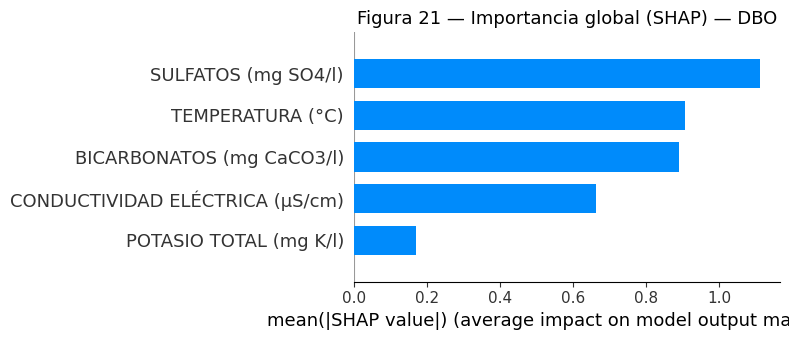

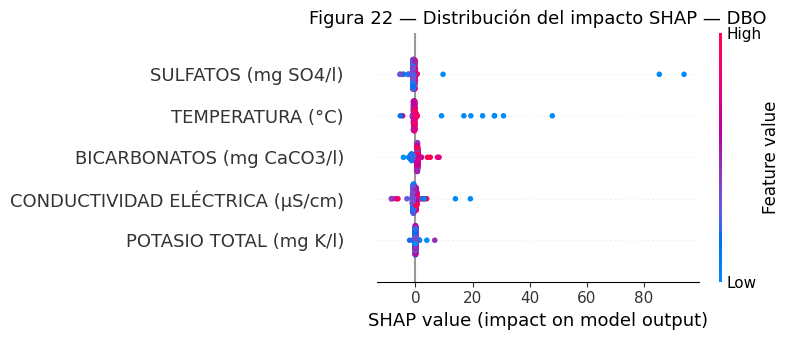

In [72]:
# SHAP — DBO (Tabla 29 + Figuras 21 y 22 en misma ejecución)
# CRÍTICO: Tabla y figuras en la misma celda, sin re-entrenar

X_shap_dbo = X_te_dbo.astype(float)
shap_ok = False
shap_values_dbo = None

# Intento 1: TreeExplainer estándar
try:
    explainer_dbo   = shap.TreeExplainer(mejor_modelo_dbo)
    shap_values_dbo = explainer_dbo.shap_values(X_shap_dbo)
    shap_ok = True
except Exception as e1:
    print(f'TreeExplainer falló: {e1}')
    try:
        explainer_dbo   = shap.Explainer(mejor_modelo_dbo, X_shap_dbo)
        shap_values_dbo = explainer_dbo(X_shap_dbo).values
        shap_ok = True
    except Exception as e2:
        print(f'Explainer genérico falló: {e2}')

if shap_ok:
    # Guardar en artefactos para export oscuro
    artefactos['shap_values_dbo'] = shap_values_dbo
    artefactos['X_shap_dbo']      = X_shap_dbo

    shap_mean_dbo = pd.DataFrame({
        'Variable': X_shap_dbo.columns,
        'Valor Medio Absoluto SHAP': np.abs(shap_values_dbo).mean(axis=0).round(4)
    }).sort_values('Valor Medio Absoluto SHAP', ascending=False)
    artefactos['compacto_shap_dbo'] = shap_mean_dbo

    print('=== Tabla 29 — SHAP mean(|SHAP|) DBO ===')
    display(shap_mean_dbo.head(10))

    shap.summary_plot(shap_values_dbo, X_shap_dbo, plot_type='bar', show=False)
    plt.title('Figura 21 — Importancia global (SHAP) — DBO', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig21_shap_bar_dbo.png', dpi=150, bbox_inches='tight')
    plt.show()

    shap.summary_plot(shap_values_dbo, X_shap_dbo, show=False)
    plt.title('Figura 22 — Distribución del impacto SHAP — DBO', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig22_shap_beeswarm_dbo.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print('Usando Permutation Importance como alternativa visual.')
    if 'compacto_pi_dbo' not in artefactos:
        res = permutation_importance(mejor_modelo_dbo, X_shap_dbo, y_te_dbo,
                                     n_repeats=30, random_state=42, n_jobs=-1)
        artefactos['compacto_pi_dbo'] = pd.DataFrame({
            'Variable': X_shap_dbo.columns,
            'Importancia Media': res.importances_mean.round(4),
            'Desviación Estándar': res.importances_std.round(4),
            'importances_raw': [res.importances[i] for i in range(len(X_shap_dbo.columns))]
        }).sort_values('Importancia Media', ascending=False)

    pi_top = artefactos['compacto_pi_dbo'].head(10)
    print('=== Tabla 29 (alt.) — Permutation Importance DBO ===')
    display(pi_top[['Variable','Importancia Media','Desviación Estándar']])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(pi_top['Variable'][::-1], pi_top['Importancia Media'][::-1],
            color='#2C5F8D', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importancia Media (Permutation Importance)')
    ax.set_title('Figura 21 — Importancia de características — DBO', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig21_pi_dbo.png', dpi=150, bbox_inches='tight')
    plt.show()


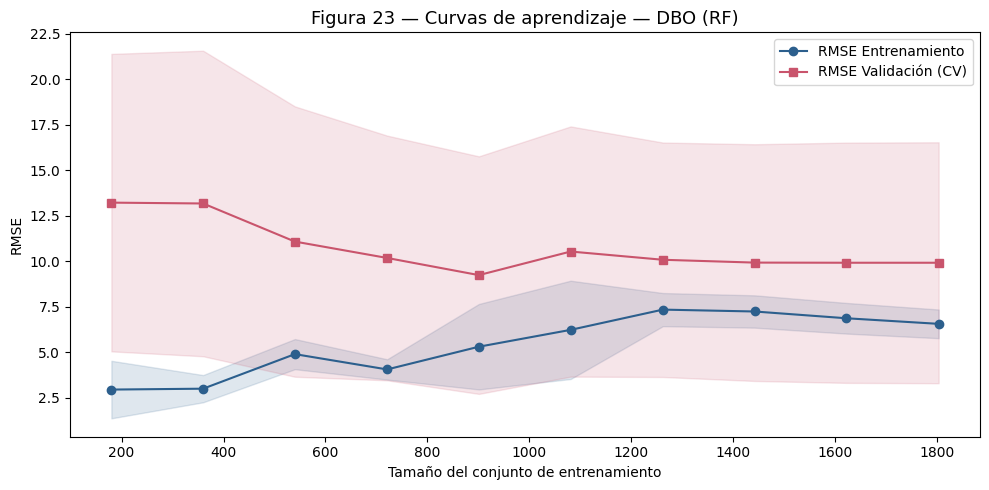

In [73]:
# Figura 23 — Curvas de aprendizaje DBO
train_sizes_dbo, train_scores_dbo, val_scores_dbo = learning_curve(
    mejor_modelo_dbo, X_dbo_full, y_dbo_full,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
    n_jobs=-1
)

train_rmse_mean = -train_scores_dbo.mean(axis=1)
train_rmse_std  =  train_scores_dbo.std(axis=1)
val_rmse_mean   = -val_scores_dbo.mean(axis=1)
val_rmse_std    =  val_scores_dbo.std(axis=1)

# Guardar en artefactos para export oscuro
artefactos['lc_dbo'] = {
    'train_sizes': train_sizes_dbo,
    'train_mean': train_rmse_mean, 'train_std': train_rmse_std,
    'val_mean':   val_rmse_mean,   'val_std':   val_rmse_std
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes_dbo, train_rmse_mean, 'o-', color='#2C5F8D', label='RMSE Entrenamiento')
ax.fill_between(train_sizes_dbo,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                alpha=0.15, color='#2C5F8D')
ax.plot(train_sizes_dbo, val_rmse_mean, 's-', color='#C9546C', label='RMSE Validación (CV)')
ax.fill_between(train_sizes_dbo,
                val_rmse_mean - val_rmse_std,
                val_rmse_mean + val_rmse_std,
                alpha=0.15, color='#C9546C')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('RMSE')
ax.set_title(f'Figura 23 — Curvas de aprendizaje — DBO ({mejor_dbo_row["modelo"]})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


---
## SECCIÓN 13 — INTERPRETABILIDAD pH

Intento 1 falló: could not convert string to float: '[7.0393105E0]'
Intento 2 falló: could not convert string to float: '[7.0393105E0]'


PermutationExplainer explainer: 452it [02:00,  3.47it/s]                         

Explainer (predict callable) OK

=== Tabla 31 — SHAP mean(|SHAP|) pH ===


,Variable,Valor Medio Absoluto SHAP
10,BICARBONATOS (mg CaCO3/l),0.0836
15,NITRATOS (mg N-NO3/l),0.0823
14,POTASIO TOTAL (mg K/l),0.0493
6,OXIGENO DISUELTO (mg O2/l),0.0423
0,TEMPERATURA (°C),0.0310
12,HIERRO TOTAL (mg Fe/l),0.0253
8,CALCIO (mg Ca/l),0.0235
4,SOLIDOS DISUELTOS (mg SD/l),0.0212
17,SULFATOS (mg SO4/l),0.0211
1,COLOR (UPC),0.0204


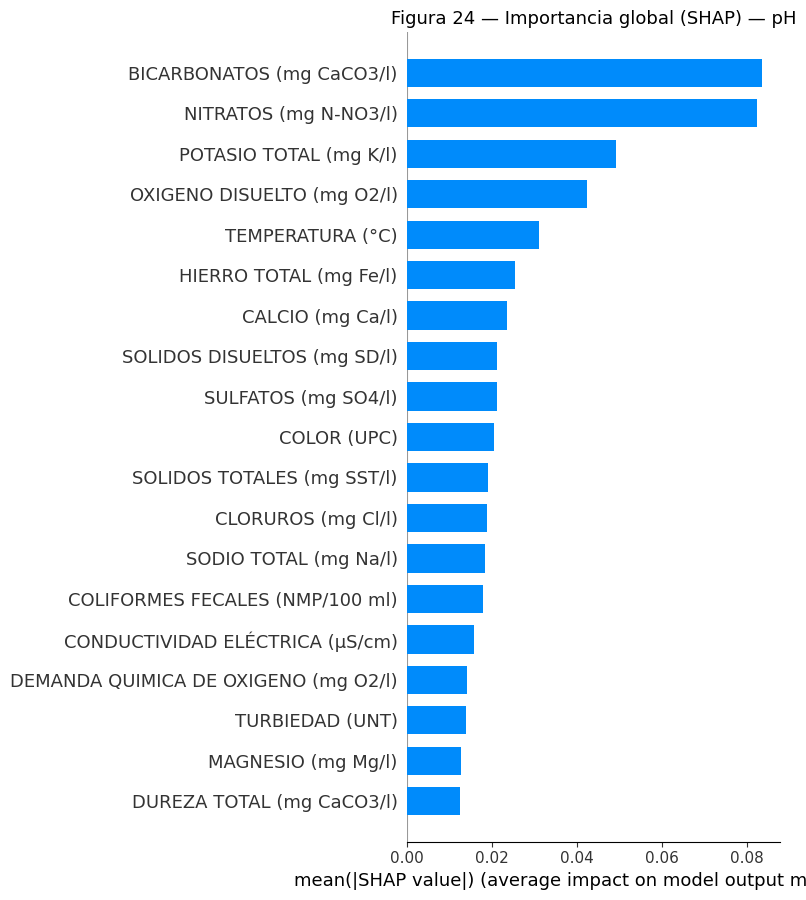

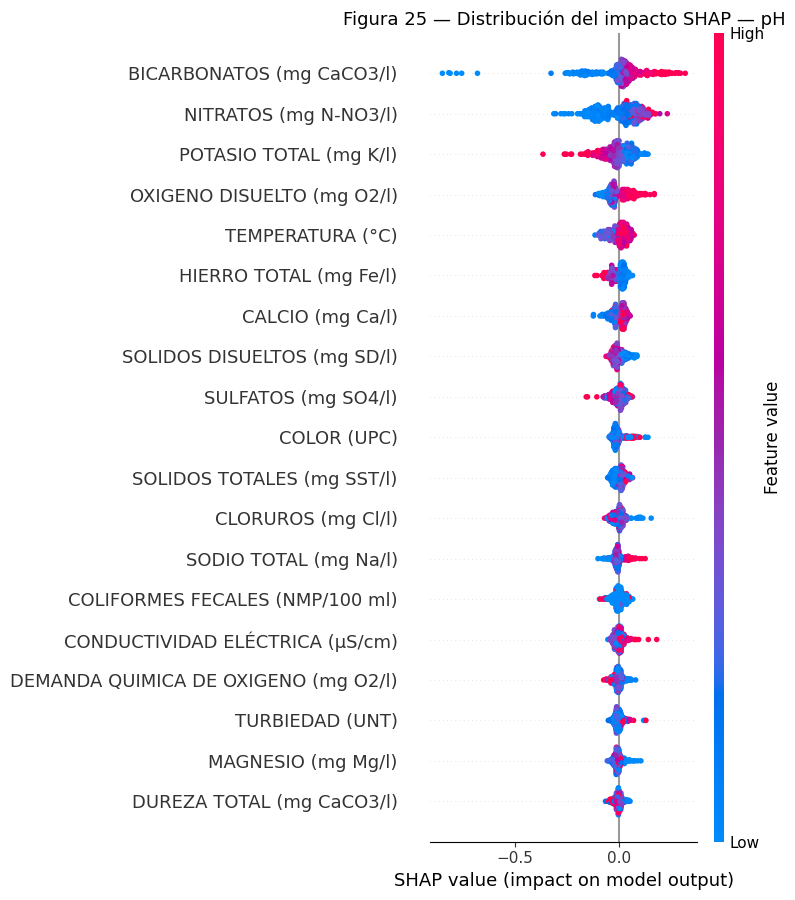

In [77]:
# SHAP — pH (Tabla 31 + Figuras 24 y 25 en misma ejecución)
# CRÍTICO: Tabla y figuras en la misma celda, sin re-entrenar

X_shap_ph  = X_te_ph.astype(float)
shap_ok_ph = False
shap_values_ph = None

# Intento 1: TreeExplainer con modelo sklearn directo
try:
    explainer_ph   = shap.TreeExplainer(mejor_modelo_ph)
    shap_values_ph = explainer_ph.shap_values(X_shap_ph)
    shap_ok_ph = True
    print('TreeExplainer (sklearn) OK')
except Exception as e1:
    print(f'Intento 1 falló: {e1}')

# Intento 2: TreeExplainer con booster nativo XGBoost
if not shap_ok_ph:
    try:
        booster_ph     = mejor_modelo_ph.get_booster()
        explainer_ph   = shap.TreeExplainer(booster_ph)
        shap_values_ph = explainer_ph.shap_values(X_shap_ph)
        shap_ok_ph = True
        print('TreeExplainer (booster nativo) OK')
    except Exception as e2:
        print(f'Intento 2 falló: {e2}')

# Intento 3: Explainer con función predict como callable
if not shap_ok_ph:
    try:
        predict_fn     = lambda x: mejor_modelo_ph.predict(pd.DataFrame(x, columns=X_shap_ph.columns))
        explainer_ph   = shap.Explainer(predict_fn, X_shap_ph)
        shap_obj       = explainer_ph(X_shap_ph)
        shap_values_ph = shap_obj.values
        shap_ok_ph = True
        print('Explainer (predict callable) OK')
    except Exception as e3:
        print(f'Intento 3 falló: {e3}')

# ── Si SHAP funcionó ──────────────────────────────────────────────────────
if shap_ok_ph:
    shap_mean_ph = pd.DataFrame({
        'Variable': X_shap_ph.columns,
        'Valor Medio Absoluto SHAP': np.abs(shap_values_ph).mean(axis=0).round(4)
    }).sort_values('Valor Medio Absoluto SHAP', ascending=False)

    artefactos['compacto_shap_ph'] = shap_mean_ph
    print('\n=== Tabla 31 — SHAP mean(|SHAP|) pH ===')
    display(shap_mean_ph.head(10))

    # Figura 24 — SHAP Bar pH
    shap.summary_plot(shap_values_ph, X_shap_ph, plot_type='bar', show=False)
    plt.title('Figura 24 — Importancia global (SHAP) — pH', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig24_shap_bar_ph.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Figura 25 — SHAP Beeswarm pH
    shap.summary_plot(shap_values_ph, X_shap_ph, show=False)
    plt.title('Figura 25 — Distribución del impacto SHAP — pH', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig25_shap_beeswarm_ph.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Fallback: PI con visualización enriquecida ────────────────────────────
else:
    print('\nUsando Permutation Importance como alternativa.')
    if 'compacto_pi_ph' not in artefactos:
        print('  Calculando Permutation Importance...')
        res = permutation_importance(mejor_modelo_ph, X_shap_ph, y_te_ph,
                                     n_repeats=30, random_state=42, n_jobs=-1)
        artefactos['compacto_pi_ph'] = pd.DataFrame({
            'Variable': X_shap_ph.columns,
            'Importancia Media': res.importances_mean.round(4),
            'Desviación Estándar': res.importances_std.round(4),
            'importances_raw': [res.importances[i] for i in range(len(X_shap_ph.columns))]
        }).sort_values('Importancia Media', ascending=False)

    pi_ph = artefactos['compacto_pi_ph'].head(10)
    print('\n=== Tabla 31 (alt.) — Permutation Importance pH ===')
    display(pi_ph[['Variable', 'Importancia Media', 'Desviación Estándar']])

    # Figura 24 — Barras PI
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(pi_ph['Variable'][::-1], pi_ph['Importancia Media'][::-1],
            xerr=pi_ph['Desviación Estándar'][::-1],
            color='#C9546C', alpha=0.85, edgecolor='white', capsize=4)
    ax.set_xlabel('Importancia Media ± Std (Permutation Importance)')
    ax.set_title('Figura 24 — Importancia de características — pH', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig24_pi_ph.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Figura 25 — Strip plot (simula beeswarm) con distribución de importancias
    fig, ax = plt.subplots(figsize=(10, 6))
    vars_top = pi_ph['Variable'].tolist()
    for idx, var in enumerate(reversed(vars_top)):
        fila = artefactos['compacto_pi_ph'][artefactos['compacto_pi_ph']['Variable'] == var]
        if not fila.empty and 'importances_raw' in fila.columns:
            vals = fila['importances_raw'].values[0]
            ax.scatter([idx] * len(vals), vals,
                       alpha=0.5, s=20, color='#C9546C')
    ax.set_xticks(range(len(vars_top)))
    ax.set_xticklabels(list(reversed(vars_top)), rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Importancia por repetición')
    ax.set_title('Figura 25 — Distribución Permutation Importance — pH', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig25_pi_strip_ph.png', dpi=150, bbox_inches='tight')
    plt.show()


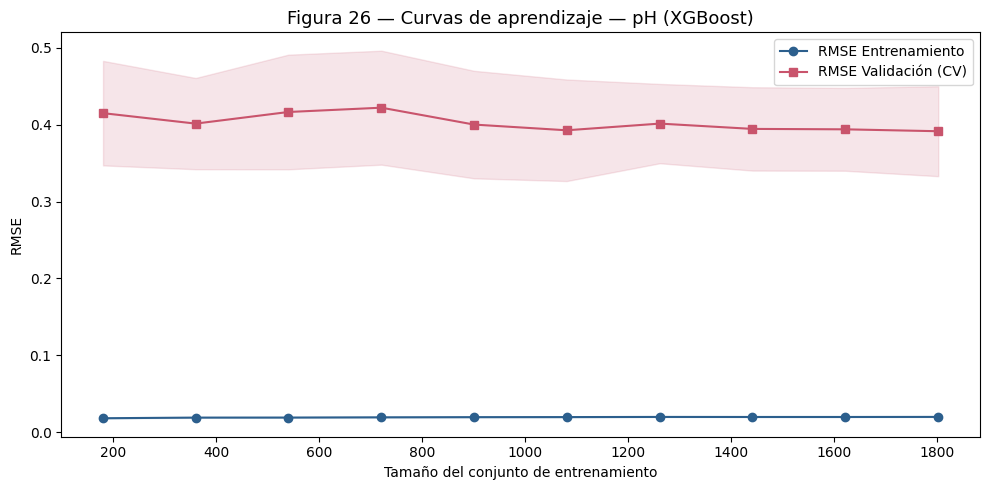

In [75]:
# Figura 26 — Curvas de aprendizaje pH
train_sizes_ph, train_scores_ph, val_scores_ph = learning_curve(
    mejor_modelo_ph, X_ph_full, y_ph_full,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
    n_jobs=-1
)

train_rmse_mean_ph = -train_scores_ph.mean(axis=1)
train_rmse_std_ph  =  train_scores_ph.std(axis=1)
val_rmse_mean_ph   = -val_scores_ph.mean(axis=1)
val_rmse_std_ph    =  val_scores_ph.std(axis=1)

# Guardar en artefactos para export oscuro
artefactos['lc_ph'] = {
    'train_sizes': train_sizes_ph,
    'train_mean': train_rmse_mean_ph, 'train_std': train_rmse_std_ph,
    'val_mean':   val_rmse_mean_ph,   'val_std':   val_rmse_std_ph
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes_ph, train_rmse_mean_ph, 'o-', color='#2C5F8D', label='RMSE Entrenamiento')
ax.fill_between(train_sizes_ph,
                train_rmse_mean_ph - train_rmse_std_ph,
                train_rmse_mean_ph + train_rmse_std_ph,
                alpha=0.15, color='#2C5F8D')
ax.plot(train_sizes_ph, val_rmse_mean_ph, 's-', color='#C9546C', label='RMSE Validación (CV)')
ax.fill_between(train_sizes_ph,
                val_rmse_mean_ph - val_rmse_std_ph,
                val_rmse_mean_ph + val_rmse_std_ph,
                alpha=0.15, color='#C9546C')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('RMSE')
ax.set_title(f'Figura 26 — Curvas de aprendizaje — pH ({mejor_ph_row["modelo"]})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


---
## RESUMEN FINAL DEL PIPELINE

RESULTADOS FINALES — Pipeline ML Calidad Agua Río Cauca

Dataset original:                  2254 registros × 56 variables
Variables tras completitud ≥80%:   27
Variables tras VIF iterativo:      19  (umbral VIF=10.0)
Combinaciones base evaluadas:      6 modelos × 4 escenarios × 2 objetivos = 48
Optimización:                      Grid Search (5 modelos) + Optuna (60 trials, XGBoost)
Total combinaciones (incluyendo tuning): 96

--- Tabla 27 — Modelos seleccionados finales ---


,Objetivo,Escenario,Modelo,R²,RMSE,MAE,Técnica
0,DBO,rfe_ph,RF,0.8979,3.3814,1.8981,grid
1,pH,vif,XGBoost,0.4115,0.2968,0.2097,optuna



--- Mejores hiperparámetros ---
DBO (RF | grid): {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
pH  (XGBoost  | optuna):  {'n_estimators': 2000, 'max_depth': 8, 'learning_rate': 0.015216251287478466, 'subsample': 0.5961610672439798, 'colsample_bytree': 0.924846322558455, 'reg_alpha': 0.014149506384703288, 'reg_lambda': 0.2191459605186484, 'min_child_weight': 2, 'gamma': 0.0018558861417794581}

--- Top 5 variables más importantes ---

  DBO (fuente: SHAP):
    SULFATOS (mg SO4/l)                           1.1106
    TEMPERATURA (°C)                              0.9056
    BICARBONATOS (mg CaCO3/l)                     0.8912
    CONDUCTIVIDAD ELÉCTRICA (µS/cm)               0.6617
    POTASIO TOTAL (mg K/l)                        0.1706

  pH (fuente: SHAP):
    BICARBONATOS (mg CaCO3/l)                     0.0840
    NITRATOS (mg N-NO3/l)                         0.0824
    POTASIO TOTAL (mg K/l)                        0.049

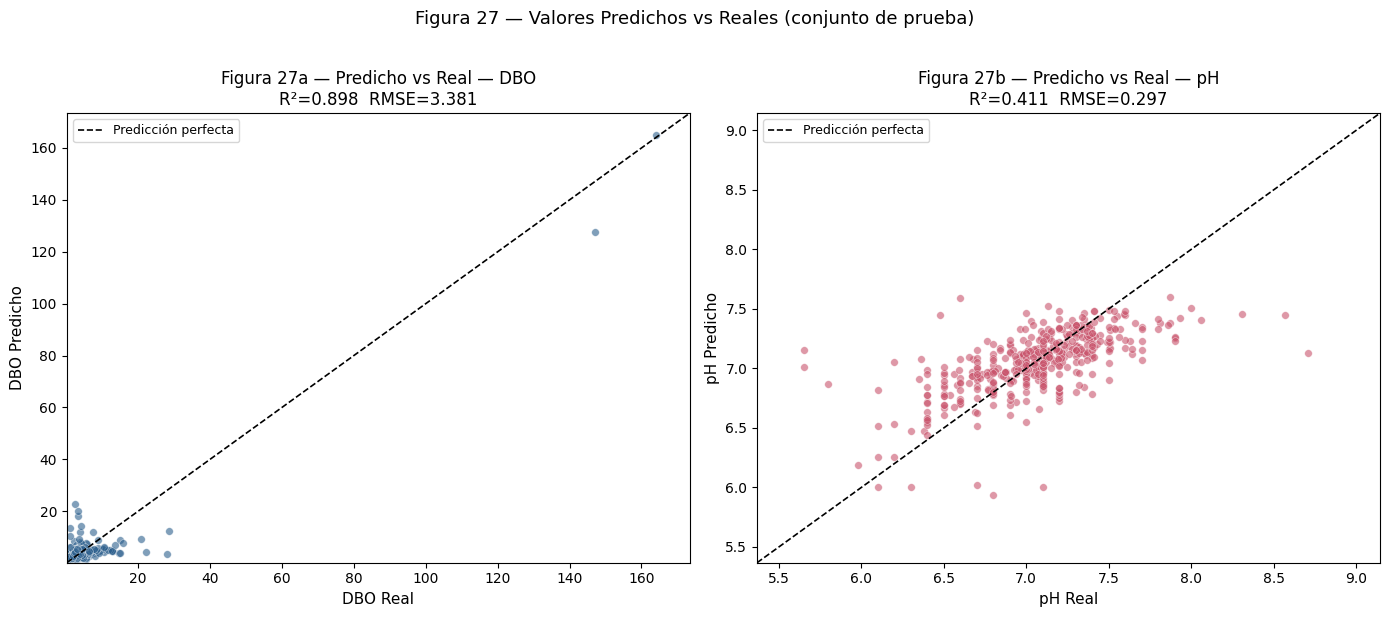


Artefactos en memoria: ['resumen_global_4esc', 'modelos_base', 'splits', 'grid_summary_test', 'modelos_grid', 'optuna_summary', 'modelos_optuna', 'optuna_studies', 'tabla_tuning_4esc', 'compacto_pi_dbo', 'compacto_shap_dbo', 'compacto_pi_ph', 'compacto_shap_ph']


In [70]:
print('=' * 65)
print('RESULTADOS FINALES — Pipeline ML Calidad Agua Río Cauca')
print('=' * 65)
print(f'\nDataset original:                  {df.shape[0]} registros × {df.shape[1]} variables')
print(f'Variables tras completitud ≥80%:   {len(columnas_mantener)}')
print(f'Variables tras VIF iterativo:      {len(cols_vif_ok)}  (umbral VIF={UMBRAL_VIF})')
print(f'Combinaciones base evaluadas:      6 modelos × 4 escenarios × 2 objetivos = 48')
print(f'Optimización:                      Grid Search (5 modelos) + Optuna ({N_TRIALS} trials, XGBoost)')
print(f'Total combinaciones (incluyendo tuning): {len(df_tuning)}')

print('\n--- Tabla 27 — Modelos seleccionados finales ---')
display(tabla_27)

# ── Mejores hiperparámetros ───────────────────────────────────────────────
print('\n--- Mejores hiperparámetros ---')
bp_dbo = mejor_dbo_row.get('best_params', 'N/A')
bp_ph  = mejor_ph_row.get('best_params',  'N/A')
print(f'DBO ({mejor_dbo_row["modelo"]} | {mejor_dbo_row["search"]}): {bp_dbo}')
print(f'pH  ({mejor_ph_row["modelo"]}  | {mejor_ph_row["search"]}):  {bp_ph}')

# ── Importancia de variables (SHAP o PI según disponibilidad) ────────────
print('\n--- Top 5 variables más importantes ---')
for obj_label, shap_key, pi_key in [
    ('DBO', 'compacto_shap_dbo', 'compacto_pi_dbo'),
    ('pH',  'compacto_shap_ph',  'compacto_pi_ph')
]:
    if shap_key in artefactos:
        top5 = artefactos[shap_key].head(5)
        col_val = 'Valor Medio Absoluto SHAP'
        fuente = 'SHAP'
    elif pi_key in artefactos:
        top5 = artefactos[pi_key].head(5)
        col_val = 'Importancia Media'
        fuente = 'Permutation Importance'
    else:
        print(f'  {obj_label}: sin datos de importancia')
        continue
    print(f'\n  {obj_label} (fuente: {fuente}):')
    for _, row in top5.iterrows():
        print(f'    {row["Variable"][:45]:<45} {row[col_val]:.4f}')

# ── Gráfico Predicho vs Real ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, modelo, X_te, y_te, label, color in [
    (axes[0], mejor_modelo_dbo, X_te_dbo, y_te_dbo, 'DBO', '#2C5F8D'),
    (axes[1], mejor_modelo_ph,  X_te_ph,  y_te_ph,  'pH',  '#C9546C'),
]:
    y_pred = modelo.predict(X_te)
    r2_val = r2_score(y_te, y_pred)
    rmse_val = sqrt(mean_squared_error(y_te, y_pred))

    # Scatter predicho vs real
    ax.scatter(y_te, y_pred, alpha=0.6, s=30, color=color, edgecolors='white', linewidth=0.4)

    # Línea perfecta (y=x)
    lim_min = min(y_te.min(), y_pred.min()) * 0.95
    lim_max = max(y_te.max(), y_pred.max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1.2, label='Predicción perfecta')

    ax.set_xlabel(f'{label} Real', fontsize=11)
    ax.set_ylabel(f'{label} Predicho', fontsize=11)
    ax.set_title(f'Figura 27{["a","b"][axes.tolist().index(ax)]} — Predicho vs Real — {label}\nR²={r2_val:.3f}  RMSE={rmse_val:.3f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

plt.suptitle('Figura 27 — Valores Predichos vs Reales (conjunto de prueba)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig27_predicho_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nArtefactos en memoria: {list(artefactos.keys())}')

In [80]:
# ═══════════════════════════════════════════════════════════
# SECCIÓN 15 — EXPORT OSCURO → presentacion_graficas/
# Regenera todas las figuras clave con fondo #09111F
# ═══════════════════════════════════════════════════════════
import os
import matplotlib as mpl

CARPETA = 'presentacion_graficas'
os.makedirs(CARPETA, exist_ok=True)

DARK_BG   = '#09111F'
DARK_TEXT = '#E8ECF4'
DARK_GRID = '#1E2D4A'
C1 = '#4E91C7'   # azul
C2 = '#E07B8A'   # rosa
C3 = '#6DBF7E'   # verde
C4 = '#F0A752'   # naranja

def dark_rc():
    """Parámetros matplotlib para fondo oscuro."""
    return {
        'figure.facecolor':  DARK_BG,
        'axes.facecolor':    DARK_BG,
        'axes.edgecolor':    DARK_TEXT,
        'axes.labelcolor':   DARK_TEXT,
        'axes.titlecolor':   DARK_TEXT,
        'xtick.color':       DARK_TEXT,
        'ytick.color':       DARK_TEXT,
        'text.color':        DARK_TEXT,
        'legend.facecolor':  DARK_GRID,
        'legend.edgecolor':  DARK_TEXT,
        'grid.color':        DARK_GRID,
        'axes.grid':         True,
        'savefig.facecolor': DARK_BG,
        'savefig.edgecolor': DARK_BG,
    }

def save_dark(nombre):
    plt.savefig(f'{CARPETA}/{nombre}', dpi=180, bbox_inches='tight',
                facecolor=DARK_BG)
    plt.close()
    print(f'  ✓ {CARPETA}/{nombre}')

# ── 1. Top-5 R² post-tuning ─────────────────────────────────────────────
df_plot = artefactos.get('tabla_tuning_4esc', pd.DataFrame())
if df_plot.empty:
    df_plot = artefactos.get('resumen_global_4esc', pd.DataFrame())

for obj_corto, c_bar in [('DBO', C1), ('pH', C2)]:
    df_obj = df_plot[df_plot['objetivo'] == obj_corto].copy()
    df_top = df_obj.nlargest(5, 'R2')
    etiquetas = [f"{r['modelo']}\n({r['escenario']})" for _, r in df_top.iterrows()]

    with mpl.rc_context(dark_rc()):
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor(DARK_BG)
        bars = ax.barh(etiquetas, df_top['R2'], color=c_bar, alpha=0.9,
                       edgecolor=DARK_TEXT, linewidth=0.8)
        for bar, v in zip(bars, df_top['R2']):
            ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=10, color=DARK_TEXT)
        ax.set_xlabel('R²', color=DARK_TEXT)
        ax.set_xlim(0, 1.15)
        ax.set_title(f'Top 5 modelos R² — {obj_corto}', fontsize=13, color=DARK_TEXT)
        ax.invert_yaxis()
        ax.tick_params(colors=DARK_TEXT)
        plt.tight_layout()
        save_dark(f'top5_r2_{obj_corto.lower()}_dark.png')

# ── 2. RMSE / MAE top-5 ─────────────────────────────────────────────────
for obj_corto in ['DBO', 'pH']:
    df_obj = df_plot[df_plot['objetivo'] == obj_corto].copy()
    df_top = df_obj.nlargest(5, 'R2')
    etiquetas = [f"{r['modelo']}\n({r['escenario']})" for _, r in df_top.iterrows()]
    x = np.arange(len(etiquetas))
    w = 0.35

    with mpl.rc_context(dark_rc()):
        fig, ax = plt.subplots(figsize=(11, 5))
        fig.patch.set_facecolor(DARK_BG)
        ax.bar(x - w/2, df_top['RMSE'], w, label='RMSE', color=C2, alpha=0.9, edgecolor=DARK_TEXT)
        ax.bar(x + w/2, df_top['MAE'],  w, label='MAE',  color=C3, alpha=0.9, edgecolor=DARK_TEXT)
        ax.set_xticks(x)
        ax.set_xticklabels(etiquetas, fontsize=8)
        ax.set_ylabel('Error', color=DARK_TEXT)
        ax.set_title(f'RMSE y MAE Top 5 — {obj_corto}', fontsize=13, color=DARK_TEXT)
        ax.legend(facecolor=DARK_GRID, edgecolor=DARK_TEXT, labelcolor=DARK_TEXT)
        ax.tick_params(colors=DARK_TEXT)
        plt.tight_layout()
        save_dark(f'rmse_mae_{obj_corto.lower()}_dark.png')

# ── 3. Permutation Importance ────────────────────────────────────────────
for obj_corto, pi_key, c_bar in [
    ('DBO', 'compacto_pi_dbo', C1),
    ('pH',  'compacto_pi_ph',  C2)
]:
    if pi_key not in artefactos:
        continue
    pi_top = artefactos[pi_key].head(10)

    with mpl.rc_context(dark_rc()):
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor(DARK_BG)
        ax.barh(pi_top['Variable'][::-1], pi_top['Importancia Media'][::-1],
                color=c_bar, alpha=0.9, edgecolor=DARK_TEXT)
        ax.set_xlabel('Importancia Media (Permutation Importance)', color=DARK_TEXT)
        ax.set_title(f'Permutation Importance — {obj_corto}', fontsize=13, color=DARK_TEXT)
        ax.tick_params(colors=DARK_TEXT)
        plt.tight_layout()
        save_dark(f'permutation_importance_{obj_corto.lower()}_dark.png')

# ── 4. SHAP bar + beeswarm (si disponible) ──────────────────────────────
for obj_corto, sv_key, xshap_key, c in [
    ('DBO', 'shap_values_dbo', 'X_shap_dbo', C1),
    ('pH',  'shap_values_ph',  'X_shap_ph',  C2)
]:
    if sv_key not in artefactos:
        continue
    sv   = artefactos[sv_key]
    Xsh  = artefactos[xshap_key]

    # Bar
    with mpl.rc_context(dark_rc()):
        shap.summary_plot(sv, Xsh, plot_type='bar', show=False,
                          color=c, plot_size=(10, 6))
        fig = plt.gcf()
        fig.patch.set_facecolor(DARK_BG)
        fig.axes[0].set_facecolor(DARK_BG)
        fig.axes[0].set_title(f'SHAP — Importancia global — {obj_corto}',
                              fontsize=13, color=DARK_TEXT)
        plt.tight_layout()
        save_dark(f'shap_importancia_{obj_corto.lower()}_dark.png')

    # Beeswarm
    with mpl.rc_context(dark_rc()):
        shap.summary_plot(sv, Xsh, show=False, plot_size=(10, 6))
        fig = plt.gcf()
        fig.patch.set_facecolor(DARK_BG)
        fig.axes[0].set_facecolor(DARK_BG)
        fig.axes[0].set_title(f'SHAP — Distribución del impacto — {obj_corto}',
                              fontsize=13, color=DARK_TEXT)
        plt.tight_layout()
        save_dark(f'shap_beeswarm_{obj_corto.lower()}_dark.png')

# ── 5. Curvas de aprendizaje ─────────────────────────────────────────────
for obj_corto, lc_key, row in [
    ('DBO', 'lc_dbo', mejor_dbo_row),
    ('pH',  'lc_ph',  mejor_ph_row)
]:
    if lc_key not in artefactos:
        continue
    lc = artefactos[lc_key]
    ts = lc['train_sizes']

    with mpl.rc_context(dark_rc()):
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor(DARK_BG)
        ax.plot(ts, lc['train_mean'], 'o-', color=C1, label='RMSE Entrenamiento')
        ax.fill_between(ts, lc['train_mean']-lc['train_std'],
                            lc['train_mean']+lc['train_std'], alpha=0.15, color=C1)
        ax.plot(ts, lc['val_mean'],   's-', color=C2, label='RMSE Validación (CV)')
        ax.fill_between(ts, lc['val_mean']-lc['val_std'],
                            lc['val_mean']+lc['val_std'],   alpha=0.15, color=C2)
        ax.set_xlabel('Tamaño del conjunto de entrenamiento', color=DARK_TEXT)
        ax.set_ylabel('RMSE', color=DARK_TEXT)
        ax.set_title(f'Curvas de aprendizaje — {obj_corto} ({row["modelo"]})',
                     fontsize=13, color=DARK_TEXT)
        ax.legend(facecolor=DARK_GRID, edgecolor=DARK_TEXT, labelcolor=DARK_TEXT)
        ax.tick_params(colors=DARK_TEXT)
        plt.tight_layout()
        save_dark(f'curva_aprendizaje_{obj_corto.lower()}_dark.png')

# ── 6. Predicho vs Real ──────────────────────────────────────────────────
with mpl.rc_context(dark_rc()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor(DARK_BG)

    for ax, modelo, X_te, y_te, label, color in [
        (axes[0], mejor_modelo_dbo, X_te_dbo, y_te_dbo, 'DBO', C1),
        (axes[1], mejor_modelo_ph,  X_te_ph,  y_te_ph,  'pH',  C2),
    ]:
        y_pred   = modelo.predict(X_te)
        r2_val   = r2_score(y_te, y_pred)
        rmse_val = sqrt(mean_squared_error(y_te, y_pred))
        lim_min  = min(y_te.min(), y_pred.min()) * 0.95
        lim_max  = max(y_te.max(), y_pred.max()) * 1.05

        ax.scatter(y_te, y_pred, alpha=0.6, s=30, color=color,
                   edgecolors=DARK_TEXT, linewidth=0.3)
        ax.plot([lim_min, lim_max], [lim_min, lim_max], '--',
                color=DARK_TEXT, linewidth=1.2, label='Predicción perfecta')
        ax.set_facecolor(DARK_BG)
        ax.set_xlabel(f'{label} Real', color=DARK_TEXT)
        ax.set_ylabel(f'{label} Predicho', color=DARK_TEXT)
        ax.set_title(f'Predicho vs Real — {label}\nR²={r2_val:.3f}  RMSE={rmse_val:.3f}',
                     fontsize=12, color=DARK_TEXT)
        ax.legend(facecolor=DARK_GRID, edgecolor=DARK_TEXT, labelcolor=DARK_TEXT)
        ax.set_xlim(lim_min, lim_max)
        ax.set_ylim(lim_min, lim_max)
        ax.tick_params(colors=DARK_TEXT)

    fig.suptitle('Valores Predichos vs Reales (conjunto de prueba)',
                 fontsize=13, color=DARK_TEXT)
    plt.tight_layout()
    save_dark('predicho_vs_real_dark.png')

print('\nExport completado. Archivos en:', CARPETA)
print(sorted(os.listdir(CARPETA)))


  ✓ presentacion_graficas/top5_r2_dbo_dark.png
  ✓ presentacion_graficas/top5_r2_ph_dark.png
  ✓ presentacion_graficas/rmse_mae_dbo_dark.png
  ✓ presentacion_graficas/rmse_mae_ph_dark.png
  ✓ presentacion_graficas/permutation_importance_dbo_dark.png
  ✓ presentacion_graficas/permutation_importance_ph_dark.png
  ✓ presentacion_graficas/shap_importancia_dbo_dark.png
  ✓ presentacion_graficas/shap_beeswarm_dbo_dark.png
  ✓ presentacion_graficas/curva_aprendizaje_dbo_dark.png
  ✓ presentacion_graficas/curva_aprendizaje_ph_dark.png
  ✓ presentacion_graficas/predicho_vs_real_dark.png

Export completado. Archivos en: presentacion_graficas
['curva_aprendizaje_dbo_dark.png', 'curva_aprendizaje_ph_dark.png', 'permutation_importance_dbo_dark.png', 'permutation_importance_ph_dark.png', 'predicho_vs_real_dark.png', 'rmse_mae_dbo_dark.png', 'rmse_mae_ph_dark.png', 'shap_beeswarm_dbo_dark.png', 'shap_importancia_dbo_dark.png', 'top5_r2_dbo_dark.png', 'top5_r2_ph_dark.png']
